# Plot Baumgartner wall data

In [2]:
def which(check,solver,method,case,geom,fluid,mesh):
    dirs_data = '/home/matar/Codes/MUSICAA/RANS/LS89/'+\
               geom+'_'+mesh+'/' 
    
    if method=='LES':
        if fluid=='air':
            dirs_data = '/home/matar/Codes/MUSICAA/PFG/LS89/'+\
                   geom+'_'+mesh+'/'
        else:
            dirs_data = '/home/matar/Codes/MUSICAA/PRS/LS89/'+\
                   geom+'_'+mesh+'/'

    if check:
        return dirs_data
    else:
        if fluid=='r134a':
            fluid = 'PRS'
        else:
            fluid = 'PFG'
        dirs_data+= f'Postproc_{fluid.lower()}/{case}/'

    return dirs_data


In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import readvars_turb as rv
import plotvars_turb as pv



# Manuscript
# ----------
checks  = [False,False,False,False,False,False,False]
solvers = ['musicaa','musicaa','musicaa','musicaa','musicaa','musicaa','musicaa']
methods = ['LES','LES','LES','LES','LES','LES','LES'] #Define isRANS
is_curv = True
cases   = ['irene_Tu0_6','adastra_5','irene_7']
endians = ['big','big','big','big','big','big','big']
geoms   = ['Mach17','optim_validation','optim']
fluids  = ['air','air','air','air','air','air','air'] #Define fluid properties
meshes  = ['C_refined','gen146_design06','design31']
L_refs = [0.010,0.010,0.010,0.010,0.010,0.010,0.010]
pitchs = [1.4633321,1.4633321,1.4633321,1.4633321,1.4633321,1.4633321,1.4633321]
wall_jmin = [True,True,True,True,True,True,True]

dirs_data = [which(checks[i],solvers[i],methods[i],case,geoms[i],fluids[i],meshes[i]) \
             for i,case in enumerate(cases)]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Get data

In [4]:
# %matplotlib widget
# %matplotlib auto
var = 'M'

import prsv_model_arr as PR

comp_data = {}
for ii,dir_data in enumerate(dirs_data):
    
    # General information
    var_list = ['rho','u','v','w','p','T','rhou','rhov','rhow','rhoe', \
                'rho**2','uu','vv','ww','uv','uw','vw','vT','p**2','T**2',\
                'mu','divloc','divloc2']
    stats1,stats2 = 1,2
    stats = stats1
    if (var not in var_list):
        stats = stats2
    dict_info = rv.read_info(dir_data)
    n_bl   = dict_info['nbloc']
    Re_in  = dict_info['Reref']
    u_in   = dict_info['Uref']
    T_in   = dict_info['Tref']
    p_in   = dict_info['Pref']
    rho_in = dict_info['Roref']
    mu_in  = dict_info['Muref']
    c_in   = dict_info['cref']
    nz     = dict_info['nz_bl1']
    # Baumgartner
    L_ref = L_refs[ii] # proj chord
    pitch = pitchs[ii]
    # isentropic Mach computation
    if fluids[ii]=='air':
        # air
        p0_in = 785000
        T0_in = 293
        p_in = 7.78e5
        u_in   = 38.3
        rho_in = 9.15
        gam_in = 1.4
    else:
        # r134a
        p0_in = 483000
        T0_in = 293
        u_in = 13.6233
        p_in = 4.79e6
        T_in = 292.8
        rho_in = 22.36
        gam_in = PR.cpcalc_tro(T_in,rho_in)/PR.cvcalc_tro(T_in,rho_in)
    norm   = u_in
    
    if methods[ii]=='RANS':
        is_RANS=True
    else:
        is_RANS=False
            
    # Wall length
    if wall_jmin[ii]:
        nw = sum([dict_info['nx_bl3'],dict_info['nx_bl4'], \
                  dict_info['nx_bl6'],dict_info['nx_bl7']])
    else:
        nw = sum([dict_info['ny_bl3'],dict_info['nx_bl4'], \
                  dict_info['ny_bl6'],dict_info['ny_bl7']])
    nw_loc = 0

    data,data2 = {},{}
    vmin,vmax = [],[]
    p0        = []
    xw,yw     = np.zeros((nw)),np.zeros((nw))
    dxw,dyw   = np.zeros((nw)),np.zeros((nw))
    dw        = np.zeros((nw))
    xm1,xp1   = np.zeros((nw)),np.zeros((nw))
    dxw       = np.zeros((nw))
    pw,cpw    = np.zeros((nw)),np.zeros((nw))
    rhow      = np.zeros((nw))
    theta,r   = np.zeros((nw)),np.zeros((nw))
    muw,la    = np.zeros((nw)),np.zeros((nw))
    rhow,y1   = np.zeros((nw))+1,np.zeros((nw))
    x1_,y1_   = np.zeros((nw)),np.zeros((nw))
    x2_,y2_   = np.zeros((nw)),np.zeros((nw))
    s         = np.zeros((nw))
    Twa,tauw  = np.zeros((nw)),np.zeros((nw))
    prms      = np.zeros((nw))
    duxw,duyw,duzw = np.zeros((nw)),np.zeros((nw)),np.zeros((nw))
    dvxw,dvyw,dvzw = np.zeros((nw)),np.zeros((nw)),np.zeros((nw))
    dwxw,dwyw,dwzw = np.zeros((nw)),np.zeros((nw)),np.zeros((nw))
    tau = np.zeros((nw,2,2))

    # For regular grid interpolation/streamlines
    u_flat   = []
    v_flat   = []
    x_flat   = []
    y_flat   = []
    var_flat = []
    rho_flat = []
    p_flat = []
    T_flat = []
    k_flat   = []
    P_flat   = []
    M_is_flat = []
    M_flat = []
    p_wake_flat = []

    # Block caracteristics
    # /!\ wall direction is clockwise
    blcar = {}
    for bl in range(n_bl):
        bl+=1
        blcar[f'block_{bl}'] = {}
        if bl==3 or bl==4 or bl==6 or bl==7:
            blcar[f'block_{bl}']['wall'] = True
        else:
            blcar[f'block_{bl}']['wall'] = False

        if (bl==3 or bl==6 or bl==7) and not wall_jmin[ii]:
            # Wall location
            blcar[f'block_{bl}']['imax'] = True
            blcar[f'block_{bl}']['jmin'] = False
        else:
            # Wall location
            blcar[f'block_{bl}']['jmin'] = True
            blcar[f'block_{bl}']['imax'] = False

    # Extract data
    for bl in range(n_bl):
        bl+=1

        # Retrieve data from readvars
        nx,ny,nz,x,y,z = rv.read_grid(dir_data+'grid_bl{}.bin'.format(bl),is_curv,endians[ii])
        bl_data,data   = rv.extr_dict(is_RANS,stats1,bl,nx,ny,dir_data,meshes[ii],data)
        bl_data2,data2 = rv.extr_dict(is_RANS,stats2,bl,nx,ny,dir_data,meshes[ii],data2)

        # isentropic Mach number
        data[f'block_{bl}']['M_is'] = np.sqrt(2/(gam_in-1)*\
              ((p0_in/bl_data['p'])**((gam_in-1)/gam_in)-1))
        M_is_flat.append(data[f'block_{bl}']['M_is'].flatten())

        # Pressure in wake
        data[f'block_{bl}']['p_wake'] = bl_data['p']/p0_in
        p_wake_flat.append(data[f'block_{bl}']['p_wake'].flatten())

        if stats==1:
            data[f'block_{bl}'][var] = bl_data[var]
        else:
            data[f'block_{bl}'][var] = bl_data2[var]
            
        # More stuff
        data[f'block_{bl}']['divloc'] = bl_data['divloc']
        data[f'block_{bl}']['M'] = bl_data2['M']
        M_flat.append(data[f'block_{bl}']['M'].flatten())
        
        # Mixed-out state
        data[f'block_{bl}']['rho'] = bl_data['rho']
        data[f'block_{bl}']['T'] = bl_data['T']
        data[f'block_{bl}']['p'] = bl_data['p']
        data[f'block_{bl}']['u'] = bl_data['u']
        data[f'block_{bl}']['v'] = bl_data['v']
        data[f'block_{bl}']['rhou'] = bl_data['rhou']
        data[f'block_{bl}']['rhov'] = bl_data['rhov']
        data[f'block_{bl}']['rhow'] = bl_data['rhow']
        data[f'block_{bl}']['M'] = bl_data2['M']
        data[f'block_{bl}']['s'] = bl_data2['s']
        data[f'block_{bl}']['rho*uu'] = bl_data2['rho*uu']
        data[f'block_{bl}']['uu'] = bl_data2['rho*uu']/bl_data['rho']
        data[f'block_{bl}']['vv'] = bl_data2['rho*vv']/bl_data['rho']
        data[f'block_{bl}']['ww'] = bl_data2['rho*ww']/bl_data['rho']
        data[f'block_{bl}']['rho*uv'] = bl_data2['rho*uv']
        data[f'block_{bl}']['rho*uw'] = bl_data2['rho*uw']
        data[f'block_{bl}']['rho*H*u'] = bl_data2['rho*h*u'] + \
        0.5*(bl_data2['rho*u**3']+bl_data2['rho*v**2*u']+bl_data2['rho*w**2*u'])

        data[f'block_{bl}']['x'],data[f'block_{bl}']['y'] = x/L_ref,y/L_ref
        
        # Flattened coords
        data[f'block_{bl}']['x_flat'] = data[f'block_{bl}']['x'].flatten()
        data[f'block_{bl}']['y_flat'] = data[f'block_{bl}']['y'].flatten()
        x_flat.append(data[f'block_{bl}']['x'].flatten())
        y_flat.append(data[f'block_{bl}']['y'].flatten())

        # Extract wall data
        if blcar[f'block_{bl}']['wall']:
            if blcar[f'block_{bl}']['imax']:
                # Wall coordinates
                xw[nw_loc:nw_loc+ny] = x[-1,:]/L_ref
                yw[nw_loc:nw_loc+ny] = y[-1,:]/L_ref
                # Compute first cell height
                x1_[nw_loc:nw_loc+ny] = x[-2,:]/L_ref
                y1_[nw_loc:nw_loc+ny] = y[-2,:]/L_ref
                if bl==6:
                    yw[nw_loc:nw_loc+ny] +=-pitch
                    y1_[nw_loc:nw_loc+ny]+=-pitch
                y1[nw_loc:nw_loc+ny]  = (np.sqrt((x1_-xw)**2+(y1_-yw)**2))[nw_loc:nw_loc+ny]
                # Cp
                pw[nw_loc:nw_loc+ny] = bl_data['p'][-1,:]
                rhow[nw_loc:nw_loc+ny] = bl_data['rho'][-1,:]
                p0.append(pw.max())
                # Tw
                Twa[nw_loc:nw_loc+ny] = bl_data['T'][-1,:]
                # Cf
                muw[nw_loc:nw_loc+ny]  = bl_data['mu'][-1,:]
                rhow[nw_loc:nw_loc+ny] = bl_data['rho'][-1,:]
                duxw[nw_loc:nw_loc+ny] = bl_data2['rho*dux'][-1,:]
                duyw[nw_loc:nw_loc+ny] = bl_data2['rho*duy'][-1,:]
                duzw[nw_loc:nw_loc+ny] = bl_data2['rho*duz'][-1,:]
                dvxw[nw_loc:nw_loc+ny] = bl_data2['rho*dvx'][-1,:]
                dvyw[nw_loc:nw_loc+ny] = bl_data2['rho*dvy'][-1,:]
                dvzw[nw_loc:nw_loc+ny] = bl_data2['rho*dvz'][-1,:]
                dwxw[nw_loc:nw_loc+ny] = bl_data2['rho*dwx'][-1,:]
                dwyw[nw_loc:nw_loc+ny] = bl_data2['rho*dwy'][-1,:]
                dwzw[nw_loc:nw_loc+ny] = bl_data2['rho*dwz'][-1,:]
                # In cartesian coordinates
                tau[nw_loc:nw_loc+ny,0,0] = (muw*2*duxw/rhow)[nw_loc:nw_loc+ny]
                tau[nw_loc:nw_loc+ny,0,1] = (muw*(duyw+dvxw)/rhow)[nw_loc:nw_loc+ny]
                tau[nw_loc:nw_loc+ny,1,0] = (muw*(duyw+dvxw)/rhow)[nw_loc:nw_loc+ny]
                tau[nw_loc:nw_loc+ny,1,1] = (muw*2*dvyw/rhow)[nw_loc:nw_loc+ny]

                # P_rms wall
                prms[nw_loc:nw_loc+ny] = np.sqrt((bl_data['p**2']-bl_data['p']**2))[-1,:]

                nw_loc+=ny

            if blcar[f'block_{bl}']['jmin']:
                # Wall coordinates
                xw[nw_loc:nw_loc+nx]  = x[:,0]/L_ref
                yw[nw_loc:nw_loc+nx]  = y[:,0]/L_ref
                # Compute first cell height
                x1_[nw_loc:nw_loc+nx] = x[:,1]/L_ref
                y1_[nw_loc:nw_loc+nx] = y[:,1]/L_ref
                # Compute wall tangential distance from cell to cell
                dxw[nw_loc:nw_loc+nx] = np.hstack((x[1:,0]-x[:-1,0],x[-2,0]-x[-1,0]))/L_ref
                dyw[nw_loc:nw_loc+nx] = np.hstack((y[1:,0]-y[:-1,0],y[-2,0]-y[-1,0]))/L_ref
                dw [nw_loc:nw_loc+nx] = np.sqrt(dxw**2+dyw**2)[nw_loc:nw_loc+nx]
                if bl==6:
                    yw[nw_loc:nw_loc+nx] +=-pitch
                    y1_[nw_loc:nw_loc+nx]+=-pitch
                y1[nw_loc:nw_loc+nx]    = (np.sqrt((x1_-xw)**2+(y1_-yw)**2))[nw_loc:nw_loc+nx]
                # Cp
                pw[nw_loc:nw_loc+nx] = bl_data['p'][:,0]
                rhow[nw_loc:nw_loc+nx] = bl_data['rho'][:,0]
                p0.append(pw.max())
                # Tw
                Twa[nw_loc:nw_loc+nx] = bl_data['T'][:,0]
                # Cf
                muw[nw_loc:nw_loc+nx]  = bl_data['mu'][:,0]
                duxw[nw_loc:nw_loc+nx] = bl_data2['rho*dux'][:,0]
                duyw[nw_loc:nw_loc+nx] = bl_data2['rho*duy'][:,0]
                duzw[nw_loc:nw_loc+nx] = bl_data2['rho*duz'][:,0]
                dvxw[nw_loc:nw_loc+nx] = bl_data2['rho*dvx'][:,0]
                dvyw[nw_loc:nw_loc+nx] = bl_data2['rho*dvy'][:,0]
                dvzw[nw_loc:nw_loc+nx] = bl_data2['rho*dvz'][:,0]
                dwxw[nw_loc:nw_loc+nx] = bl_data2['rho*dwx'][:,0]
                dwyw[nw_loc:nw_loc+nx] = bl_data2['rho*dwy'][:,0]
                dwzw[nw_loc:nw_loc+nx] = bl_data2['rho*dwz'][:,0]
                # In cartesian coordinates
                tau[nw_loc:nw_loc+nx,0,0] = (muw*2*duxw/rhow)[nw_loc:nw_loc+nx]
                tau[nw_loc:nw_loc+nx,0,1] = (muw*(duyw+dvxw)/rhow)[nw_loc:nw_loc+nx]
                tau[nw_loc:nw_loc+nx,1,0] = (muw*(duyw+dvxw)/rhow)[nw_loc:nw_loc+nx]
                tau[nw_loc:nw_loc+nx,1,1] = (muw*2*dvyw/rhow)[nw_loc:nw_loc+nx]

                # P_rms wall
                prms[nw_loc:nw_loc+nx] = np.sqrt((bl_data['p**2']-bl_data['p']**2))[:,0]

                nw_loc+=nx
                
        # TKE terms
        # =========
        bl_data['util'] = bl_data['rhou']/bl_data['rho']
        bl_data['vtil'] = bl_data['rhov']/bl_data['rho']
        bl_data['wtil'] = bl_data['rhow']/bl_data['rho']
        data[f'block_{bl}']['k'] = 1/2*(bl_data['uu']+bl_data['util']**2- \
                                      2*bl_data['u'] *bl_data['util']   + \
                                        bl_data['vv']+bl_data['vtil']**2- \
                                      2*bl_data['v'] *bl_data['vtil']   + \
                                        bl_data['ww']+bl_data['wtil']**2- \
                                      2*bl_data['w'] *bl_data['wtil']     )
        data[f'block_{bl}']['k'] = data[f'block_{bl}']['k']/u_in**2
        # Production of TKE
        P11 = (bl_data2[f'rho*uu']-bl_data['rhou']*bl_data['util'])*bl_data2['rho*dux']
        P12 = (bl_data2[f'rho*uv']-bl_data['rhov']*bl_data['util'])*bl_data2['rho*duy']
        P13 = (bl_data2[f'rho*uw']-bl_data['rhow']*bl_data['util'])*bl_data2['rho*duz']
        P21 = (bl_data2[f'rho*uv']-bl_data['rhou']*bl_data['vtil'])*bl_data2['rho*dvx']
        P22 = (bl_data2[f'rho*vv']-bl_data['rhov']*bl_data['vtil'])*bl_data2['rho*dvy']
        P23 = (bl_data2[f'rho*vw']-bl_data['rhow']*bl_data['vtil'])*bl_data2['rho*dvz']
        P31 = (bl_data2[f'rho*uw']-bl_data['rhou']*bl_data['wtil'])*bl_data2['rho*dwx']
        P32 = (bl_data2[f'rho*vw']-bl_data['rhov']*bl_data['wtil'])*bl_data2['rho*dwy']
        P33 = (bl_data2[f'rho*ww']-bl_data['rhow']*bl_data['wtil'])*bl_data2['rho*dwz']
        data[f'block_{bl}']['P_k'] = -(P11+P12+P13+P21+P22+P23+P31+P32+P33)/bl_data['rho']
        data[f'block_{bl}']['P_k'] = data[f'block_{bl}']['P_k']/rho_in/u_in**3*L_ref
        # Separate terms
        data[f'block_{bl}']['P_k_compr'] = -(P11+P22+P33)/rho_in/u_in**3*L_ref
        data[f'block_{bl}']['P_k_shear'] = data[f'block_{bl}']['P_k']-\
                                           data[f'block_{bl}']['P_k_compr']
        # Store
        data[f'block_{bl}']['k_flat'] = data[f'block_{bl}']['k'].flatten()
        data[f'block_{bl}']['P_k_flat'] = data[f'block_{bl}']['P_k'].flatten()
        k_flat.append(data[f'block_{bl}']['k'].flatten())
        P_flat.append(data[f'block_{bl}']['P_k'].flatten())
                
            
        # Operations for grid interpolation and streamlines
        u_flat.append(bl_data['u'].flatten())
        v_flat.append(bl_data['v'].flatten())
        rho_flat.append(bl_data['rho'].flatten())
        p_flat.append(bl_data['p'].flatten())
        T_flat.append(bl_data['T'].flatten())
        var_flat.append(data[f'block_{bl}'][var].flatten())
        # Per block
        data[f'block_{bl}']['u_flat'] = bl_data['u'].flatten()
        data[f'block_{bl}']['v_flat'] = bl_data['v'].flatten()
        data[f'block_{bl}']['rho_flat'] = bl_data['rho'].flatten()
        data[f'block_{bl}']['p_flat'] = bl_data['p'].flatten()
        data[f'block_{bl}']['T_flat'] = bl_data['T'].flatten()
        data[f'block_{bl}']['var_flat'] = data[f'block_{bl}'][var].flatten()

        # Operations for Mach number and speed of sound
        data[f'block_{bl}']['u'] = bl_data['u']
        data[f'block_{bl}']['v'] = bl_data['v']
        data[f'block_{bl}']['w'] = bl_data['w']
        data[f'block_{bl}']['rho'] = bl_data['rho']
        data[f'block_{bl}']['mu'] = bl_data['mu']
        data[f'block_{bl}']['M'] = bl_data2['M']
        data[f'block_{bl}']['vort']  =-bl_data2['b3']*L_ref/u_in

        vmin_ = data[f'block_{bl}'][var].min()
        vmax_ = data[f'block_{bl}'][var].max()
        vmin.append(vmin_)
        vmax.append(vmax_)

    # Add more useful stuff
    #######################

    # Inlet data
    data['n_bl'] = n_bl
    data['u_in'] = u_in
    data['p_in'] = p_in
    data['p0_in'] = p0_in
    data['T_in'] = T_in
    data['mu_in'] = mu_in
    data['rho_in'] = rho_in
    data['vmin'] = min(vmin)
    data['vmax'] = max(vmax)
    data['L_ref'] = L_ref
    data['norm'] = norm
    data['s_in'] = data[f'block_1']['s'][0,0]

    # Outlet pitchwise average
    i = 45
    rho_out = 0.5*(np.mean(data['block_8']['rho'][i,:])+np.mean(data['block_9']['rho'][i,:]))
    u_out = 0.5*(np.mean(data['block_8']['u'][i,:])+np.mean(data['block_9']['u'][i,:]))
    v_out = 0.5*(np.mean(data['block_8']['v'][i,:])+np.mean(data['block_9']['v'][i,:]))
    U_out = np.sqrt(u_out**2+v_out**2)
    mu_out = 0.5*(np.mean(data['block_8']['mu'][i,:])+np.mean(data['block_9']['mu'][i,:]))
    M_out = 0.5*(np.mean(data['block_8']['M'][i,:])+np.mean(data['block_9']['M'][i,:]))
    thet_out = np.arctan(v_out/u_out)*180/np.pi
    Re_out = rho_out*U_out*L_ref/mu_out
    print('Re_out =',Re_out)
    print('M_out =',M_out)
    print('thet_out =',thet_out)
    
    # Wall coordinates
    if wall_jmin[ii]:
        def rearrange(x,d):
            len_ = d['nx_bl3']+d['nx_bl4']
            # save bl6 coords
            x_ = np.zeros(d['nx_bl6'])
            x_ = x[len_:len_+d['nx_bl6']].copy()
            # rotate array
            x[len_:len_+d['nx_bl7']] = x[-d['nx_bl7']:].copy()
            x[-d['nx_bl6']:] = x_.copy()

            return x
    else:
        def rearrange(x,d):
            len_ = d['ny_bl3']+d['nx_bl4']
            # save bl6 coords
            x_ = np.zeros(d['ny_bl6'])
            x_ = x[len_:len_+d['ny_bl6']].copy()
            # rotate array
            x[len_:len_+d['ny_bl7']] = x[-d['ny_bl7']:].copy()
            x[-d['ny_bl6']:] = x_.copy()

            return x
    
    xw = rearrange(xw,dict_info)
    yw = rearrange(yw,dict_info)
    dw = rearrange(dw,dict_info)
    pw = rearrange(pw,dict_info)
    rhow = rearrange(rhow,dict_info)
    data['pw'] = pw
    data['rhow'] = rhow
    
    # Translate everything so stagnation point is @ (0,0)
    ind_p0 = np.argmax(pw) # index of P0 to start wall coords
    xw_p0 = xw[ind_p0]
    yw_p0 = yw[ind_p0]
    s = np.hstack((np.array([0]),np.sqrt((xw[1:]-xw[:-1])**2+(xw[1:]-xw[:-1])**2)[ind_p0:],\
                   np.sqrt((xw[1:]-xw[:-1])**2+(xw[1:]-xw[:-1])**2)[:ind_p0]))
    s = np.cumsum(s)
    # # Rotate coordinates by stagger angle
    thet = 43.3*np.pi/180
    coords = np.vstack((xw,yw))
    R = np.array([[np.cos(thet),-np.sin(thet)],[np.sin(thet),np.cos(thet)]])
    coords = np.matmul(R,coords)
    # xw = coords[0,:]
    # yw = coords[1,:]
    xw = xw-xw.min()
    xw = xw/(xw.max()-xw.min())
    yw = yw/(xw.max()-xw.min())
    # Store
    data['xw'] = xw
    data['yw'] = yw
    data['s']  = s
    
    # Isentropic Mach number
    data['p0'] = p0_in
    data['p/p0'] = pw/data['p0']
    if fluids[ii]=='air':
        gam = 1.4
    else:
        gam = PR.cpcalc_tro(T_in,rho_in)/PR.cvcalc_tro(T_in,rho_in)
        print('gam_nov =',gam)
    gam1= gam-1
    data['M_is'] = np.sqrt(((data['p/p0'])**(-gam1/gam)-1)*2/gam1)
    
    # Wall normals
    nwall = np.zeros((nw,2))
    twall = np.zeros((nw,2))
    with open(dir_data+'norm_surf.dat','r') as f:
        dat = np.loadtxt(f)
        nxwalldl = dat[:,0]
        nywalldl = dat[:,1]
        nxwall = dat[:,2]
        nywall = dat[:,3]
        # dl     = dat[:,4]
        ijacob = dat[:,4]
        nwall[:,0],nwall[:,1] = nxwall,nywall
        nwalldl = np.sqrt(nxwalldl**2+nywalldl**2)
        data['nwall'] = nwall

    # Wall friction
    twall[:,0] = nwall[:,1]
    twall[:,1] = -nwall[:,0]
    tauw = ((tau[...,0,0]*nwall[:,0]+tau[...,0,1]*nwall[:,1])*twall[:,0] + \
            (tau[...,1,0]*nwall[:,0]+tau[...,1,1]*nwall[:,1])*twall[:,1]).copy()
        
    # Rearrange
    nwall[:,0] = rearrange(nwall[:,0],dict_info)
    nwall[:,1] = rearrange(nwall[:,1],dict_info)
    twall[:,0] = rearrange(twall[:,0],dict_info)
    twall[:,1] = rearrange(twall[:,1],dict_info)
    tauw = rearrange(tauw,dict_info)
    y1 = rearrange(y1,dict_info)
    x1 = rearrange(nwalldl,dict_info)/L_ref
    muw = rearrange(muw,dict_info)
    utau = np.sqrt(abs(tauw)/rhow)
    data['cf'] = -tauw/(0.5*rho_in*u_in**2)

    # Non dimensional wall data
    normw = utau
    data['yp'] = y1*L_ref*utau/muw*rhow
    # data['xp'] = x1*L_ref*utau/muw*rhow
    data['xp'] = dw*L_ref*utau/muw*rhow
    data['tauw'] = tauw
    data['utau'] = utau
    data['rhow'] = rhow
    data['muw']  = muw

    # Flattened data
    data['x_flat'] = np.hstack(x_flat)
    data['y_flat'] = np.hstack(y_flat)
    data['M_is_flat'] = np.hstack(M_is_flat)
    np.nan_to_num(data['M_is_flat'],0)
    data['M_flat'] = np.hstack(M_flat)
    data['p_wake_flat'] = np.hstack(p_wake_flat)

    data['u_flat'] = np.hstack(u_flat)
    data['v_flat'] = np.hstack(v_flat)
    data['rho_flat'] = np.hstack(rho_flat)
    data['p_flat'] = np.hstack(p_flat)
    data['T_flat'] = np.hstack(T_flat)
    data['var_flat'] = np.hstack(var_flat)
    
    # Store
    comp_data[f'{ii}'] = data.copy()
    
print('done')

Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...


/tmp/ipykernel_1386141/760148131.py:133: RuntimeWarning: invalid value encountered in sqrt
  data[f'block_{bl}']['M_is'] = np.sqrt(2/(gam_in-1)*\


Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Re_out = 1329200.1644647014
M_out = 1.683988955894029
thet_out = -76.12187779276013
gam_nov = 1.1025547108622586
Reading grid...
Reading stats...


/tmp/ipykernel_1386141/760148131.py:422: RuntimeWarning: invalid value encountered in sqrt
  data['M_is'] = np.sqrt(((data['p/p0'])**(-gam1/gam)-1)*2/gam1)


Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Re_out = 1333715.5182086318
M_out = 1.6832143663548842
thet_out = -76.0247268480321
gam_nov = 1.1025547108622586
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Reading grid...
Reading stats...
Reading stats...
Re_out = 1327359.211

# Plot field

/tmp/ipykernel_1386141/1671685389.py:15: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\


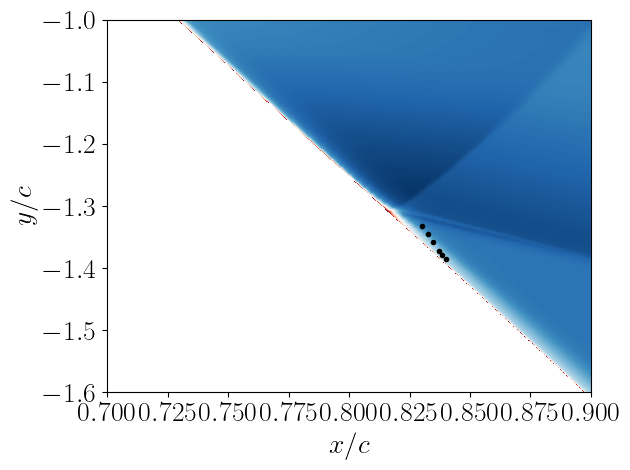

In [5]:
# %matplotlib auto

font = 20
markerscale=1

ii=2

var = 'v'

plt.figure()
plt.rcParams['text.usetex'] = True
 
for bl in range(n_bl):
    bl+=1
    plt.pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                   comp_data[f'{ii}'][f'block_{bl}']['y'],\
                   comp_data[f'{ii}'][f'block_{bl}'][var],\
                   # vmin=7e4,vmax=4.8e5,cmap='RdBu_r') # p
                   vmin=-280,vmax=20,cmap='RdBu_r') # v
                   # vmin=3,vmax=7,cmap='RdBu_r') # rho

plt.xlabel(r'$x/c$',fontsize=font)
plt.ylabel(r'$y/c$',fontsize=font)
plt.xticks(fontsize=font)

plt.yticks(fontsize=font)
# plt.xlim(0.70,1.30) # TE
# plt.ylim(-0.9,-0.5)
plt.xlim(0.7,0.9) # SWBLI
plt.ylim(-1.6,-1)


# Sensor locations
# ================
# # TE
# ind_i_list = [140,142,680,710,750,790]
# ind_j_list = [120,249,240,204,172,150]
# bl_list = [6,6,5,5,5,5]
# for i,ind_i in enumerate(ind_i_list):
#     ind_j = ind_j_list[i]
#     bl = bl_list[i]
#     plt.plot(comp_data[f'{ii}'][f'block_{bl}']['x'][ind_i,ind_j],\
#              comp_data[f'{ii}'][f'block_{bl}']['y'][ind_i,ind_j],'.k')
# # SWBLI
# ind_i_list = [130,140,150,160,170,180,190,200]
# ind_j_list = [50,50,50,50,50,50,50,50]
# bl_list = [7,7,7,7,7,7,7,7]
# for i,ind_i in enumerate(ind_i_list):
#     ind_j = ind_j_list[i]
#     bl = bl_list[i]
#     plt.plot(comp_data[f'{ii}'][f'block_{bl}']['x'][ind_i,ind_j],\
#              comp_data[f'{ii}'][f'block_{bl}']['y'][ind_i,ind_j],'.k')
# SWBLI shear layer
ind_i_list = [180,190,200,210,215,220]
ind_j_list = [95,85,75,60,55,55]
ind_j_list = np.array([95,85,75,60,55,55])-5
bl_list = [7,7,7,7,7,7]
for i,ind_i in enumerate(ind_i_list):
    ind_j = ind_j_list[i]
    bl = bl_list[i]
    plt.plot(comp_data[f'{ii}'][f'block_{bl}']['x'][ind_i,ind_j],\
             comp_data[f'{ii}'][f'block_{bl}']['y'][ind_i,ind_j],'.k')
    
# plt.axis('scaled')
plt.tight_layout()
# plt.savefig('Figures_LS59_Stefan/Mis_wall_mesh_convergence.pdf',format='pdf')
plt.show()

# Plot $M_{is}$

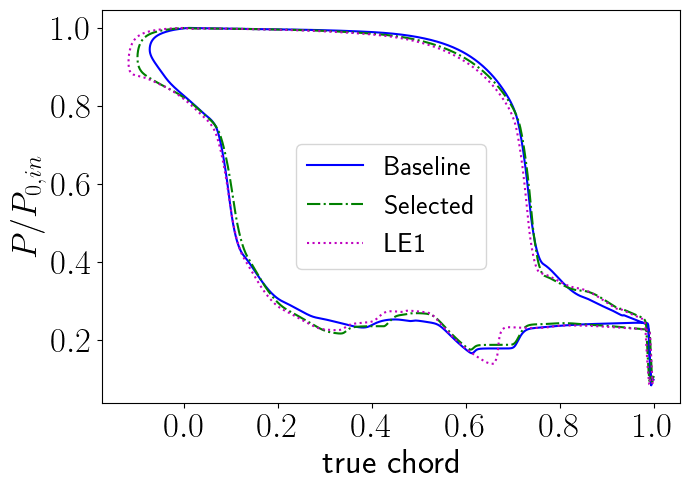

In [6]:
# %matplotlib widget

font = 25
markerscale=2
lw=1.5
markersize=5
markevery=40

# legends = [r'$Tu=0\%$',r'$Tu=4\%$',r'$Tu=8\%$',r'$Tu=0\%$  Air']
legends = [r'Baseline',r'Selected',r'LE1']
styles = ['-b','-.g',':m']

plt.figure(figsize=(7,5))
plt.rcParams['text.usetex'] = True
for ii,dir_data in enumerate(dirs_data):
    
    true_chord = (comp_data[f'{ii}']['xw']*np.cos(-75*np.pi/180)+comp_data[f'{ii}']['yw']*np.sin(-75*np.pi/180)).copy()
    true_chord /= true_chord.max()
    
    plt.plot(true_chord,comp_data[f'{ii}']['pw']/p0_in,\
            styles[ii],linewidth=lw,markevery=markevery,markerfacecolor='none',markersize=markersize,\
             label=legends[ii])

# Exp data
# plt.plot(x,Mis_sanz,'sk',markerfacecolor='None')
plt.xlabel(r'true chord',fontsize=font)
# plt.ylabel(r'$M_{is}$',fontsize=font)
plt.ylabel(r'$P/P_{0,in}$',fontsize=font)
plt.xticks(fontsize=font)
plt.yticks(fontsize=font)
plt.legend(prop={'size':font-5},markerscale=markerscale)
plt.tight_layout()
# plt.savefig('Figures_LS59_Stefan/Mis_wall_mesh_convergence.pdf',format='pdf')
# plt.savefig('Figures/DLES14/Pw.pdf',format='pdf')

# plt.savefig('Figures/Manuscript/Pw_comp_LES.pdf',format='pdf')
plt.show()

# plt.figure()
# for ii,dir_data in enumerate(dirs_data):
#     xw = comp_data[f'{ii}']['xw']
#     yw = comp_data[f'{ii}']['yw']
#     plt.plot(xw,yw)
# plt.show()
    

# Plot $C_f$

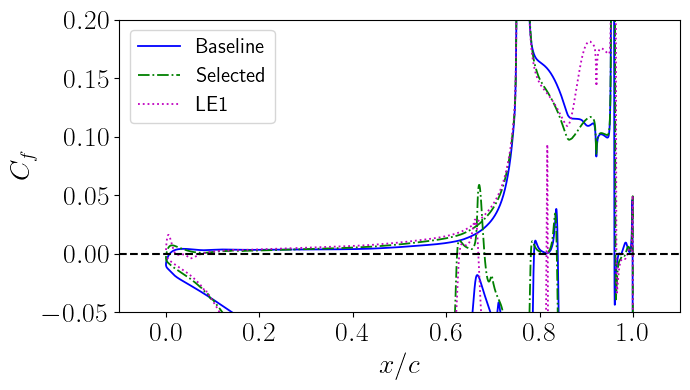

In [7]:
# %matplotlib widget

font = 20
markerscale=2
lw=1.3
markersize=5
markevery=20

# All
legends = [r'$Tu=0\%$',r'$Tu=4\%$',r'$Tu=8\%$',r'$Tu=0\%$  Air']
styles  = ['-b','-^r','--k','-or']
legends = [r'Baseline',r'Selected',r'LE1']
styles = ['-b','-.g',':m']

# Suction side
start = 0
end   = -1

plt.figure(figsize=(7,4))
# plt.figure(figsize=(5,4))
# fig, ax = plt.subplots(figsize=(5,4))
plt.rcParams['text.usetex'] = True
# dirs_data = [dirs_data[0],dirs_data[-1]]
for ii,dir_data in enumerate(dirs_data):
    # if ii!=0:
    #     ii=3
    plt.plot(comp_data[f'{ii}']['xw'][start:end],comp_data[f'{ii}']['cf'][start:end],\
             styles[ii],linewidth=lw,markevery=markevery,markersize=markersize,markerfacecolor='none',\
             label=legends[ii])

plt.plot([-0.1,1.1],[0,0],'--k')
plt.xlabel(r'$x/c$',fontsize=font)
plt.ylabel(r'$C_f$',fontsize=font)
plt.xticks(fontsize=font)
plt.yticks(fontsize=font)
plt.yticks(fontsize=font)
plt.ylim(-0.05,0.2)
plt.xlim(-0.1,1.1)
plt.legend(prop={'size':font-5},markerscale=markerscale)
plt.tight_layout()

# plt.savefig('Figures/ETMM_presentation/Cf_suction_1.pdf',format='pdf')
plt.show()


# Plot $y^+$

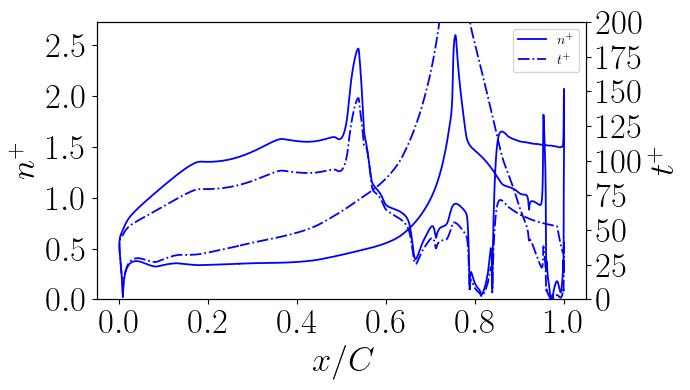

In [7]:
font=25
markerscale=2
markersize=6
markevery=3
lw=1.3

legends = ['RANS','LES']
styles  = ['-b','-^r','--k','-or']

fig,ax = plt.subplots(figsize=(7,4))
plt.rcParams['text.usetex'] = True
# yp
for ii,dir_data in enumerate(dirs_data[2:]):
    ii=0
    xw = comp_data[f'{ii}']['xw']
    yp = comp_data[f'{ii}']['yp']
    ax.plot(xw,yp,styles[ii][-1],linewidth=lw,label=r'$n^+$')
plt.ylabel(rf'$n^+$',fontsize=font)
plt.xlabel(rf'$x/C$',fontsize=font)
plt.xticks(fontsize=font)
plt.yticks(fontsize=font)
plt.ylim(0,)

# xp
ax2=ax.twinx()
for ii,dir_data in enumerate(dirs_data[2:]):
    ii=0
    xw = comp_data[f'{ii}']['xw']
    xp = comp_data[f'{ii}']['xp']
    ax2.plot(xw,xp,'-.'+styles[ii][-1],linewidth=lw,label=r'$t^+$')
plt.ylim(0,200)
plt.ylabel(rf'$t^+$',fontsize=font)
plt.xlabel(rf'$x/C$',fontsize=font)
plt.xticks(fontsize=font)
plt.yticks(fontsize=font)


# # ax.set_xlim(1,100)
# # ax.set_ylim(0.0,)
# plt.xlabel(r'$s$',fontsize=font)
# plt.ylabel(r'$y^+$',fontsize=font)
# plt.xticks(fontsize=font)
# plt.yticks(fontsize=font)
# plt.legend(prop={'size':font-10},markerscale=markerscale)
# plt.show()


# legends
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2,prop={'size':font-15},markerscale=markerscale)
plt.tight_layout()
# plt.savefig('Figures/DLES14/yp.pdf',format='pdf')
plt.show()

# Plot $C_p$ at TE

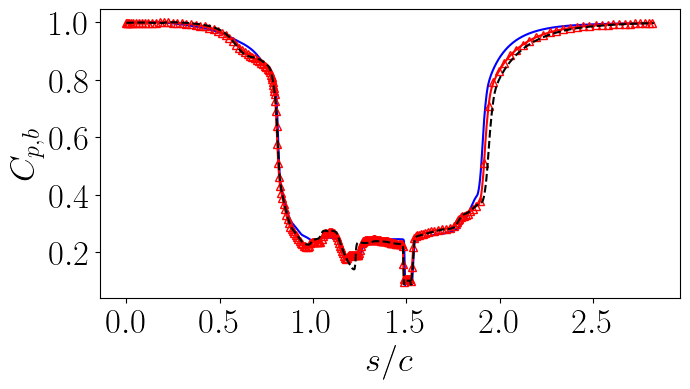

In [8]:
# %matplotlib widget

font = 25
markerscale=5
markersize=6
markevery=10


plt.figure(figsize=(7,4))
plt.rcParams['text.usetex'] = True
for ii,dir_data in enumerate(dirs_data):
    p0_in = comp_data[f'{ii}']['p0_in']
    pw = comp_data[f'{ii}']['pw']
    rhow = comp_data[f'{ii}']['rhow']
    
    if wall_jmin[ii]:
        p_ref = comp_data[f'{ii}'][f'block_7']['p'][-1,0]
        V2 = (comp_data[f'{ii}'][f'block_7']['u']**2+comp_data[f'{ii}'][f'block_7']['v']**2+\
              comp_data[f'{ii}'][f'block_7']['w']**2)[-1,:]
    else:
        p_ref = comp_data[f'{ii}'][f'block_7']['p'][-1,-1]
        V2 = (comp_data[f'{ii}'][f'block_7']['u']**2+comp_data[f'{ii}'][f'block_7']['v']**2+\
              comp_data[f'{ii}'][f'block_7']['w']**2)[:,-1][::-1]
    V = np.sqrt(V2)
    V_ref = V.max()
    
    # Cp definition by Rossiter Pref taken upstream the TE
    cp_te = (pw-p_ref)/(p0_in-p_ref)
    
    # Cp definition by Denton Vref taken upstream the TE
    cp_te = (pw-p_ref)/(0.5*rhow*V_ref**2)
    
    # Cp using p0_in
    cp_te = pw/p0_in
    
    plt.plot(comp_data[f'{ii}']['s'],cp_te,styles[ii],markersize=markersize,\
             markerfacecolor='none',markevery=markevery)
    
# plt.xlim(2.1,2.25)
# plt.ylim(-0.25,0.05)
plt.ylabel(r'$C_{p,b}$',fontsize=font)
plt.xlabel(r'$s/c$',fontsize=font)
plt.xticks(fontsize=font)
plt.yticks(fontsize=font)
# plt.legend()
plt.tight_layout()
plt.show()


# Plot $M_{is}$ and TE pressure

/tmp/ipykernel_413072/825176779.py:62: RuntimeWarning: divide by zero encountered in divide
  theta = np.arctan(y_/x_)[::-1]*180/np.pi
/tmp/ipykernel_413072/825176779.py:62: RuntimeWarning: divide by zero encountered in divide
  theta = np.arctan(y_/x_)[::-1]*180/np.pi
/tmp/ipykernel_413072/825176779.py:62: RuntimeWarning: divide by zero encountered in divide
  theta = np.arctan(y_/x_)[::-1]*180/np.pi


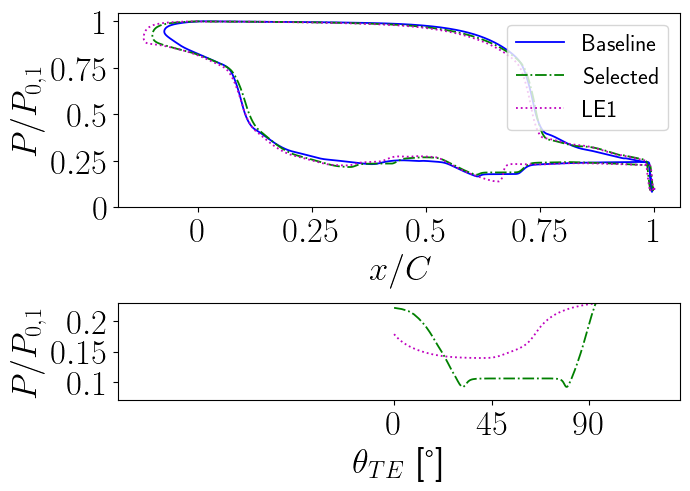

In [9]:
# %matplotlib widget

font = 25
markerscale=2
lw=1.3
markersize=5
markevery=20
legends = ['RANS','DDES','LES']
styles  = ['-b','-^r','^g','^r','--r','-.k','-og']
legends = [r'Baseline',r'Selected',r'LE1']
styles = ['-b','-.g',':m']

# Indices of TE
x1s = [269,1870,1160]
x2s = [321,2020,1306]

# x1s = [0,0,0]
# x2s = [-1,-1,-1]

fig,axs = plt.subplots(2,1,figsize=(7,5),sharex=False,sharey=False, gridspec_kw={'height_ratios': [2, 1]})
plt.rcParams['text.usetex'] = True
for ii,dir_data in enumerate(dirs_data):
    
    # Mis
    true_chord = comp_data[f'{ii}']['xw']*np.cos(-75*np.pi/180)+comp_data[f'{ii}']['yw']*np.sin(-75*np.pi/180)
    true_chord /= true_chord.max()
    axs[0].plot(true_chord,comp_data[f'{ii}']['pw']/p0_in,\
            styles[ii],linewidth=lw,markevery=markevery,markersize=markersize,markerfacecolor='none',\
             label=legends[ii])
    # # Cp_b
    # # s = comp_data[f'{ii}']['s'][x1s[ii]:x2s[ii]]
    # sx = comp_data[f'{ii}']['xw'][x1s[ii]+1:x2s[ii]+1]-comp_data[f'{ii}']['xw'][x1s[ii]:x2s[ii]]
    # sy = comp_data[f'{ii}']['yw'][x1s[ii]+1:x2s[ii]+1]-comp_data[f'{ii}']['yw'][x1s[ii]:x2s[ii]]
    # # s = np.hstack((np.array([0]),np.sqrt(sx**2 + sy**2)))
    # s = np.sqrt(sx**2 + sy**2)
    # s = np.cumsum(s)
    # smin = s.min()
    # s = s-smin
    # smax = s.max()
    # s = s/smax
    
    # TE coordinates
    x_ = comp_data[f'{ii}']['xw'][x1s[ii]:x2s[ii]]
    y_ = comp_data[f'{ii}']['yw'][x1s[ii]:x2s[ii]]
    centerx = (x_[0]+x_[-1])/2
    centery = (y_[0]+y_[-1])/2
    x_ = x_-centerx
    y_ = y_-centery
    # Rotate
    thet = 25*np.pi/180
    coords = np.vstack((x_,y_))
    R = np.array([[np.cos(thet),-np.sin(thet)],[np.sin(thet),np.cos(thet)]])
    coords = np.matmul(R,coords)
    x_ = coords[0,:]
    y_ = coords[1,:]
    x_ = x_-x_.min()
    y_ = y_/(x_.max()-x_.min())
    x_ = x_/(x_.max()-x_.min())
    comp_data[f'{ii}']['x_'] = x_
    comp_data[f'{ii}']['y_'] = y_
    # # Get TE angle
    theta = np.arctan(y_/x_)[::-1]*180/np.pi
    theta += -theta[0]
    comp_data[f'{ii}']['theta'] = theta
    
    axs[1].plot(theta,comp_data[f'{ii}']['pw'][x1s[ii]:x2s[ii]]/p0_in,\
            styles[ii],linewidth=lw,markevery=markevery//5,markersize=markersize,markerfacecolor='none',\
             label=legends[ii])
    # axs[1].plot(comp_data[f'{ii}']['xw'][x1s[ii]:x2s[ii]],comp_data[f'{ii}']['p/p0'][x1s[ii]:x2s[ii]],\
    #         styles[ii],linewidth=lw,markevery=markevery//5,markersize=markersize,markerfacecolor='none',\
    #          label=legends[ii])
    
    # ticks
    if ii==0:
        # axs[0].set_ylim(1,4)
        axs[0].set_xlabel(r'$x/C$',fontsize=font)
        # axs[0].set_ylabel(r'$M_{is}$',fontsize=font)
        # axs[0].set_yticks([0,1,2])
        # axs[0].set_xticklabels([])
        # axs[0].set_yticklabels([r'$1$',r'$1$',r'$2$'],fontsize=font)
        axs[0].set_ylabel(r'$P/P_{0,1}$',fontsize=font)
        axs[0].set_xticks([0,0.25,0.5,0.75,1])
        axs[0].set_yticks([0,0.25,0.5,0.75,1])
        axs[0].set_xticklabels([r'$0$',r'$0.25$',r'$0.5$',r'$0.75$',r'$1$'],fontsize=font)
        axs[0].set_yticklabels([r'$0$',r'$0.25$',r'$0.5$',r'$0.75$',r'$1$'],fontsize=font)
        axs[0].set_ylim(0,)
        
        axs[1].set_ylim(0.07,0.23)
        axs[1].set_xlabel(r'$\theta_{TE}$ [\textdegree]',fontsize=font)
        # axs[1].set_xlabel(r'$s$',fontsize=font)
        axs[1].set_ylabel(r'$P/P_{0,1}$',fontsize=font)
        axs[1].set_xticks([0,45,90,135,180])
        # axs[1].set_xticks([0,0.25,0.5,0.75,1])
        axs[1].set_yticks([0.1,0.15,0.2])
        axs[1].set_xticklabels([r'$0$',r'$45$',r'$90$',r'$135$',r'$180$'],fontsize=font)
        # axs[1].set_xticklabels([r'$0$',r'$0.25$',r'$0.50$',r'$0.75$',r'$1$'],fontsize=font)
        axs[1].set_yticklabels([r'$0.1$',r'$0.15$',r'$0.2$'],fontsize=font)


# plt.xlabel(r'$x/c$',fontsize=font)
# plt.ylabel(r'$M_{is}$',fontsize=font)
# plt.xticks(fontsize=font)
# plt.yticks(fontsize=font)
axs[0].legend(prop={'size':font-8},markerscale=markerscale)
plt.tight_layout()
# plt.savefig('Figures/ETMM_presentation/Mis_wall.pdf',format='pdf')
# plt.savefig('Figures/ASME/Mis_Cpb_3D_shroud.pdf',format='pdf')
# plt.savefig('Figures/ASME/Mis_Cpb_3D_hub.pdf',format='pdf')
# plt.savefig('Figures/ASME/pw_Cpb_3D_hub.pdf',format='pdf')
plt.show()




# plt.figure()
# for ii,dir_data in enumerate(dirs_data):
#     # plt.plot(comp_data[f'{ii}']['xw'],comp_data[f'{ii}']['yw'],styles[ii])
#     # plt.plot(comp_data[f'{ii}']['theta'],styles[ii])
#     plt.plot(comp_data[f'{ii}']['x_'],comp_data[f'{ii}']['y_'],styles[ii])
#     # plt.plot()
# plt.axis('scaled')
# # plt.show()

# Get wake profiles

In [17]:
import scipy.interpolate as si

# Interpolate data on line
#=========================
def line_interp(data,var,lims,bl_list_io):

    var_flat_ = []
    x_flat_ = []
    y_flat_ = []
    for bl in bl_list_io:
        x_flat_.append(data[f'block_{bl}']['x'].flatten())
        y_flat_.append(data[f'block_{bl}']['y'].flatten())
        var_flat_.append(data[f'block_{bl}'][f'{var}'].flatten())
        
    var_flat = np.hstack(var_flat_)
    x_flat = np.hstack(x_flat_)
    y_flat = np.hstack(y_flat_)

    # Create line
    N = 1000
    x1,y1 = lims[0],lims[1]
    x2,y2 = lims[2],lims[3]
    x_interp = np.linspace(x1,x2,N)
    y_interp = np.linspace(y1,y2,N)

    # Interpolate
    var_interp = si.griddata((x_flat,y_flat),var_flat,(x_interp,y_interp),method='linear')
    line = np.cumsum(np.sqrt((x_interp[1:]-x_interp[:-1])**2+(y_interp[1:]-y_interp[:-1])**2))
    
    return var_interp,y_interp

# Useful
# ======
def find_closest_index(arr,target):
    closest_index = 0
    closest_difference = abs(arr[0] - target)  # Initialize with the difference between the first element and the target

    for i in range(1, len(arr)):
        difference = abs(arr[i] - target)
        if difference < closest_difference:
            closest_difference = difference
            closest_index = i

    return closest_index


# Compute mixed-out state
# =======================
def mixed_out(data):

    # 'bar' means mixed-out
    data['m_bar'] = np.mean(data['rhou_interp']) # mass
    data['v_bar'] = np.mean(data['rho*uv_interp'])/data['m_bar']
    data['w_bar'] = np.mean(data['rho*uw_interp'])/data['m_bar']
    data['vv_bar'] = data['v_bar']**2
    data['ww_bar'] = data['w_bar']**2
    data['H_bar'] = np.mean(data['rho*H*u_interp'])/data['m_bar']

    # For local use
    m_bar  = data['m_bar']
    H_bar  = data['H_bar']
    vv_bar = data['vv_bar']
    ww_bar = data['ww_bar']
    
    # Integrals
    x_mom = np.mean(data[f'rho*uu_interp']+data[f'p_interp'])
    y_mom = np.mean(data[f'rho*uv_interp'])
    z_mom = np.mean(data[f'rho*uw_interp'])

    # error
    err1 = 1
    err2 = 1
    eps = 1e-5

    # Initial conditions: average conditions along interp line
    p_ = np.mean(data[f'p_interp'])
    rho_ = np.mean(data[f'rho_interp'])
    T_ = np.mean(data[f'T_interp'])
    u_ = np.mean(data[f'rhou_interp']/data[f'rho_interp'])
    e_ = PR.ecalc_pro(p_,rho_,T_)
    h_ = e_ + p_/rho_

    while err1>=eps and err2>=eps:

        # Initialize
        p = p_
        rho = rho_
        T = T_
        u = T_
        e = e_
        h = h_
        u = u_

        # Function to cancel
        f = h + 0.5*m_bar**2/rho**2 + 0.5*(vv_bar+ww_bar) - H_bar

        # Against pressure
        # ================
        # Derivative of energy w.r.t pressure
        dedp = PR.dedTcalc_tro(T,rho)/PR.dpdTcalc_tro(T,rho)

        # Derivative of enthalpy w.r.t pressure
        dhdp = dedp + 1/rho

        # Derivative w.r.t pressure
        dfdp = dhdp

        # Against density
        # ===============
        # Derivative of pressure w.r.t density
        dpdrho = -PR.dpdvcalc_tro(T,rho)/rho**2

        # Derivative of energy w.r.t density at constant pressure
        dedrho_p = PR.dedrocalc_tro(T,rho) - PR.dedTcalc_tro(T,rho)*dpdrho/PR.dpdTcalc_tro(T,rho)

        # Derivative of enthalpy w.r.t density at constant oressure
        dhdrho_p = dedrho_p - p/rho**2

        # Derivative w.r.t density
        dfdrho = dhdrho_p - m_bar**2/rho**3

        # Update
        # ======
        # Newton
        rho_ = rho - f/dfdrho
        # Velocity from mass
        u_ = m_bar/rho_
        # Pressure from momentum
        p_ = x_mom-u_*m_bar
        # Rest from pressure and density
        T_ = PR.tcalc_pro(p_,rho_,T_)
        e_ = PR.ecalc_pro(p_,rho_,T_)
        h_ = e_ + p_/rho_

        # Check convergence
        # =================
        err1 = abs(p_-p)/p
        err2 = abs(rho_-rho)/rho

    p_bar = p_
    rho_bar = rho_
    T_bar = T_
    u_bar = u_
    c_bar = np.sqrt(PR.c2calc_tro(T_bar,rho_bar))
    M_bar = np.sqrt(u_bar**2+vv_bar+ww_bar)/c_bar

    # Store
    data['p_bar'] = p_bar
    data['rho_bar'] = rho_bar
    data['T_bar'] = T_bar
    data['s_bar'] = PR.scalc_tro(T_bar,rho_bar)
    data['u_bar'] = u_bar
    data['V2_bar'] = u_bar**2+vv_bar+ww_bar
    data['M_bar'] = M_bar


    return data

In [18]:
x1,x2 = 1.5,1.5
bl_list = [8,9]    
var_list = ['rho','T','p','uu','vv','ww','rhou','rho*uu','rho*uv',\
            'rho*uw','rho*H*u','M',var]

for ii,dir_data in enumerate(dirs_data):
    
    data = comp_data[f'{ii}'].copy()
    
    ind_x = find_closest_index(data['block_8']['x'][:,0],x1)
    y1 = data['block_8']['y'][ind_x,:].min()
    y2 = y1+pitch-2e-2
    lims = [x1,y1,x2,y2]
    # Loop over variables
    for var in var_list:
        data[f'{var}_interp'],data['y_interp'] = \
             line_interp(data,var,lims,bl_list)
        print(var)
        
    # Store
    data = mixed_out(data)
    comp_data[f'{ii}'] = data.copy()
    
    print(ii)
print('done')

rho
T
p
uu
vv
ww
rhou
rho*uu
rho*uv
rho*uw
rho*H*u
M
p
0
rho
T
p
uu
vv
ww
rhou
rho*uu
rho*uv
rho*uw
rho*H*u
M
p
1
rho
T
p
uu
vv
ww
rhou
rho*uu
rho*uv
rho*uw
rho*H*u
M
p
2
done


# Check line position

/tmp/ipykernel_416197/881379502.py:10: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(data[f'block_{bl}']['x'],data[f'block_{bl}']['y'],data[f'block_{bl}'][var],vmin=0,vmax=2)
/tmp/ipykernel_416197/881379502.py:10: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(data[f'block_{bl}']['x'],data[f'block_{bl}']['y'],data[f'block_{bl}'][var],vmin=0,vmax=2)
/tmp/ipykernel_416197/881379502.py:10: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calcul

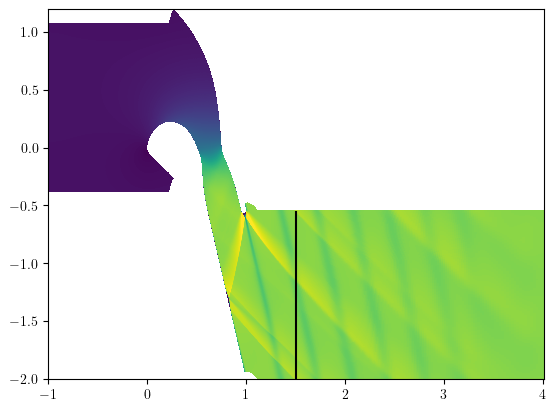

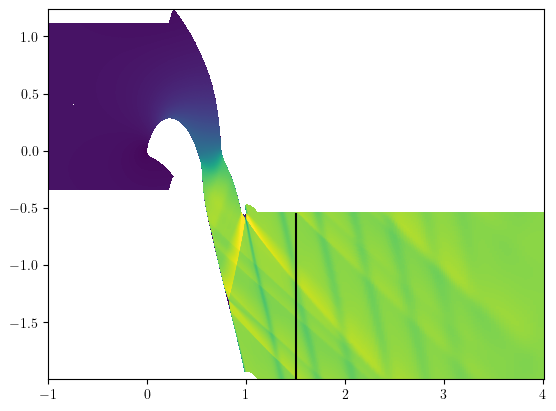

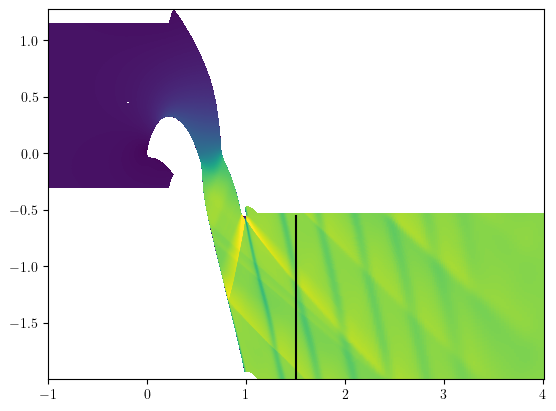

In [19]:
var = 'M'

for ii,dir_data in enumerate(dirs_data):
    
    plt.figure()
    data = comp_data[f'{ii}'].copy()
    
    for bl in range(n_bl):
        bl+=1
        plt.pcolormesh(data[f'block_{bl}']['x'],data[f'block_{bl}']['y'],data[f'block_{bl}'][var],vmin=0,vmax=2)
    plt.plot(np.zeros(data['y_interp'].shape)+x1,data['y_interp'],'-k')

plt.show()


# Plot wake profiles

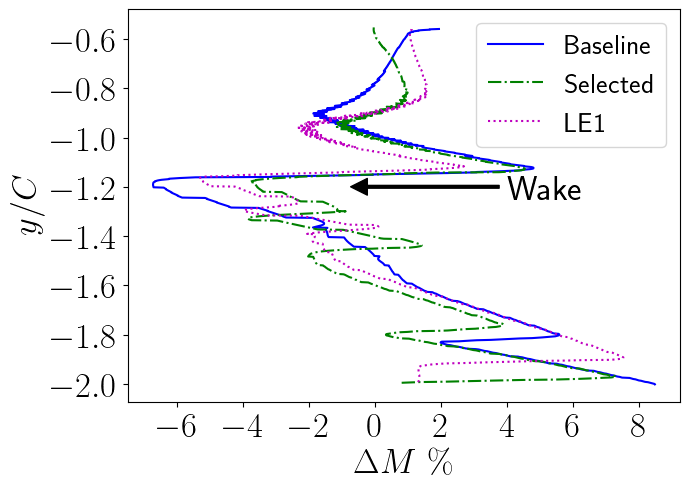

In [20]:
font = 25
markerscale=2
lw=1.3
markersize=5
markevery=20
legends = ['Baseline',r'$\min(J_1)$',r'Trade-off',r'$\min(J_2)$',r'$Tu=0\%$  Air']
styles = ['-b',':r','-.g','--m']
legends = [r'Baseline',r'Selected',r'LE1']
styles = ['-b','-.g',':m']

# legends = [r'Trade-off',r'Worst',r'$Tu=0\%$  Air']
# styles = ['-.g','-^k']

var = 'M'

plt.figure(figsize=(7,5))
plt.rcParams['text.usetex'] = True
for ii,dir_data in enumerate(dirs_data):
    
    data = comp_data[f'{ii}'].copy()
    
#     plt.plot(data[f'{var}_interp'],data['y_interp'],styles[ii],markevery=markevery,markerfacecolor='none',markersize=markersize,label=legends[ii])
    
#     # Add mixed-out Mach number
#     plt.plot(np.zeros(data['y_interp'].shape)+data['M_bar'],data['y_interp'],'--'+styles[ii][-1])

    # Deviations about mixed-out Mach number
    dev_M = (data[f'{var}_interp']-data['M_bar'])/data['M_bar']*1e2
    plt.plot(dev_M,data['y_interp'],styles[ii],markevery=markevery,markerfacecolor='none',markersize=markersize,label=legends[ii])

plt.xticks(fontsize=font)
plt.yticks(fontsize=font)
plt.xlabel(r'$\Delta M$ $\%$',fontsize=font)
plt.ylabel(r'$y/C$',fontsize=font)
plt.legend(prop={'size':font-5},markerscale=1)

# Annotations
plt.annotate('',xy=(-1,-1.2),xytext=(4,-1.2),
             arrowprops=dict(facecolor='black',shrink=0.05,width=2),
               fontsize=font)
plt.annotate(r'Wake',xy=(4,-1.25),fontsize=font)

plt.tight_layout()

# plt.savefig('Figures/Manuscript/M_wake_comp_LES.pdf')
plt.show()

# Plot stagnation loss

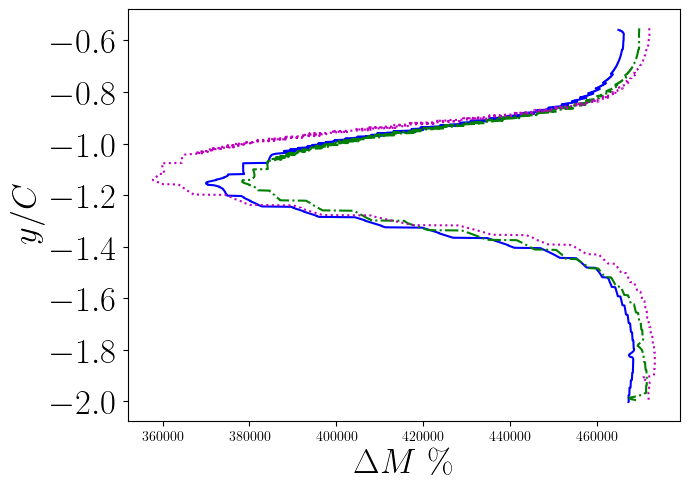

In [21]:
import total_prsv

font = 25
markerscale=2
lw=1.3
markersize=5
markevery=20
legends = ['Baseline',r'$\min(J_1)$',r'Trade-off',r'$\min(J_2)$',r'$Tu=0\%$  Air']
styles = ['-b',':r','-.g','--m']
legends = [r'Baseline',r'Selected',r'LE1']
styles = ['-b','-.g',':m']

# legends = [r'Baseline',r'Worst',r'$Tu=0\%$  Air']
# styles = ['-b','-^k']

var = 'M'

plt.figure(figsize=(7,5))
plt.rcParams['text.usetex'] = True
for ii,dir_data in enumerate(dirs_data):
    
    data = comp_data[f'{ii}'].copy()
    
    # Compute stgnation quantities
    p = data[f'p_interp'].copy()
    rho = data[f'rho_interp'].copy()
    V2 = (data[f'uu_interp']+data[f'vv_interp']+data[f'ww_interp']).copy()
    p0,T0,ro0 = total_prsv.total(p,rho,V2)
    

    plt.plot(p0,data['y_interp'],styles[ii],markevery=markevery,markerfacecolor='none',markersize=markersize,label=legends[ii])

# plt.xticks(fontsize=font)
plt.yticks(fontsize=font)
plt.xlabel(r'$\Delta M$ $\%$',fontsize=font)
plt.ylabel(r'$y/C$',fontsize=font)
# plt.legend(prop={'size':font-5},markerscale=1)
plt.tight_layout()

# plt.savefig('Figures/Manuscript/M_wake_comp_Pareto_RANS.pdf')
plt.show()

# Plot scalar wake profiles at several locations

In [37]:
# Interpolate data on line
#=========================
def line_interp_entropy(data,var,lims,bl_list_io):

    var_flat_ = []
    x_flat_ = []
    y_flat_ = []
    for bl in bl_list_io:
        x_flat_.append(data[f'block_{bl}']['x'].flatten())
        x_flat_.append(data[f'block_{bl}']['x'].flatten())
        y_flat_.append(data[f'block_{bl}']['y'].flatten())
        y_flat_.append(data[f'block_{bl}']['y'].flatten()+pitch)
        var_flat_.append(data[f'block_{bl}'][f'{var}'].flatten())
        var_flat_.append(data[f'block_{bl}'][f'{var}'].flatten())
        
    var_flat = np.hstack(var_flat_)
    x_flat = np.hstack(x_flat_)
    y_flat = np.hstack(y_flat_)

    # Create line
    N = 1000
    x1,y1 = lims[0],lims[1]
    x2,y2 = lims[2],lims[3]
    x_interp = np.linspace(x1,x2,N)
    y_interp = np.linspace(y1,y2,N)

    # Interpolate
    var_interp = si.griddata((x_flat,y_flat),var_flat,(x_interp,y_interp),method='linear')
    line = np.cumsum(np.sqrt((x_interp[1:]-x_interp[:-1])**2+(y_interp[1:]-y_interp[:-1])**2))
    
    return var_interp,y_interp



x1s = [1.05,1.25,1.5]
x2s = [1.05,1.25,1.5]
y1s = [-1.75,-1.1,-1.9]
y2s = [-1.75+pitch,-1.1+pitch,-1.9+pitch]
# y1s = [-1.75,-1.75,-1.75]
# y2s = [-1.75+pitch,-1.75+pitch,-1.75+pitch]

bl_list = [5,6,7,8,9]

for ii,dir_data in enumerate(dirs_data):
    
    data = comp_data[f'{ii}'].copy()
    for i,x1 in enumerate(x1s):
        x1 = x1s[i]
        x2 = x2s[i]
        y1 = y1s[i]
        y2 = y2s[i]
        lims = [x1,y1,x2,y2]
        # Loop over variables
        data[f's_interp_{x1}'],data[f'y_interp_{x1}'] = \
             line_interp_entropy(data,'s',lims,bl_list)
        
        # Store
    comp_data[f'{ii}'] = data.copy()
    
    print(ii)
print('done')

0
1
2
done


# Plot entropy in wake

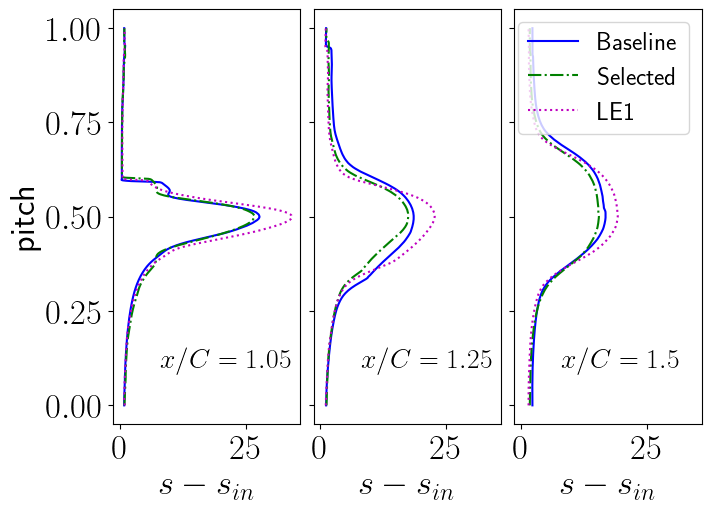

In [49]:
font = 25
markerscale=2
lw=1.3
markersize=5
markevery=20
legends = ['Baseline',r'$\min(J_1)$',r'Trade-off',r'$\min(J_2)$',r'$Tu=0\%$  Air']
styles = ['-b',':r','-.g','--m']
legends = [r'Baseline',r'Selected',r'LE1']
styles = ['-b','-.g',':m']
pos = [1.05,1.25,1.50]

# legends = [r'Trade-off',r'Worst',r'$Tu=0\%$  Air']
# styles = ['-.g','-^k']

i=1

fig,axs = plt.subplots(1,3,figsize=(7,5),sharex=True,sharey=True,constrained_layout=True) # NICFD5
# fig,axs = plt.subplots(1,3,figsize=(12,5),sharex=True,sharey=True,constrained_layout=True) # Manuscript
plt.rcParams['text.usetex'] = True
for i,x1 in enumerate(x1s):
    for ii,dir_data in enumerate(dirs_data):

        # Get data
        data = comp_data[f'{ii}'].copy()
        s = data[f's_interp_{x1s[i]}'].copy()
        y = data[f'y_interp_{x1s[i]}'].copy()
        s_in = data[f'block_1']['s'][0,0]

        # Center about maximum
        ind_max = np.argmax(s)
        s_max = s.max()
        mid = s.size//2
        
        if ind_max<mid:
            s = np.roll(s,mid-ind_max)
        else:
            s = np.roll(s,mid-ind_max)
        y = np.linspace(0,1,s.size)        

        axs[i].plot(s-s_in,y,styles[ii],
                 markevery=markevery,markerfacecolor='none',markersize=markersize,label=legends[ii])

    # axs[i].set_xticks([0,25,50],fontsize=font)
    # axs[i].set_yticks([],fontsize=font)
    axs[i].tick_params(axis='both',which='major',labelsize=font)
    axs[i].set_xlabel(r'$s-s_{in}$',fontsize=font)
    
    # Add position
    axs[i].annotate(fr'$x/C={pos[i]}$',xy=(8,0.1),fontsize=font-5)
    
axs[0].set_ylabel(r'pitch',fontsize=font)
axs[2].legend(prop={'size':font-7},markerscale=1)

# plt.savefig('Figures/NICFD5/Entropy_wake_comp_LES.pdf')
# plt.savefig('Figures/Manuscript/Entropy_wake_comp_LES.pdf')
plt.show()

# Plot stagnation loss at several locations in wake

In [42]:
import total_prsv

x1s = [1.05,1.25,1.5]
x2s = [1.05,1.25,1.5]
y1s = [-1.75,-1.1,-1.9]
y2s = [-1.75+pitch,-1.1+pitch,-1.9+pitch]
# y1s = [-1.75,-1.75,-1.75]
# y2s = [-1.75+pitch,-1.75+pitch,-1.75+pitch]

bl_list = [5,6,7,8,9]

var_list = ['p','rho','uu','vv','ww']

for ii,dir_data in enumerate(dirs_data):
    
    data = comp_data[f'{ii}'].copy()
    for i,x1 in enumerate(x1s):
        x1 = x1s[i]
        x2 = x2s[i]
        y1 = y1s[i]
        y2 = y2s[i]
        lims = [x1,y1,x2,y2]
        # Loop over variables
        for var in var_list:
            data[f'{var}_interp_{x1}'],data[f'y_interp_{x1}'] = \
                 line_interp_entropy(data,var,lims,bl_list)
        
        # Stagnation
        p = data[f'p_interp_{x1}'].copy()
        rho = data[f'rho_interp_{x1}'].copy()
        V2 = (data[f'uu_interp_{x1}']+data[f'vv_interp_{x1}']+data[f'ww_interp_{x1}']).copy()
        p0,T0,ro0 = total_prsv.total(p,rho,V2)
        data[f'p0_{x1}'] = p0.copy()
        
    # Store
    comp_data[f'{ii}'] = data.copy()
    
    print(ii)
print('done')

KeyboardInterrupt: 

In [ ]:
font = 25
markerscale=2
lw=1.3
markersize=5
markevery=20
legends = ['Baseline',r'$\min(J_1)$',r'Trade-off',r'$\min(J_2)$',r'$Tu=0\%$  Air']
styles = ['-b',':r','-.g','--m']
legends = [r'Baseline',r'Selected',r'LE1']
styles = ['-b','-.g',':m']

# legends = [r'Baseline',r'Worst',r'$Tu=0\%$  Air']
# styles = ['-.g','-^k']

i=1

fig,axs = plt.subplots(1,3,figsize=(12,5),sharex=True,sharey=True,constrained_layout=True)
plt.rcParams['text.usetex'] = True
for i,x1 in enumerate(x1s):
    for ii,dir_data in enumerate(dirs_data):

        # Get data
        data = comp_data[f'{ii}'].copy()
        p0 = data[f'p0_{x1s[i]}'].copy()
        y = data[f'y_interp_{x1s[i]}'].copy()
        p0_in = 483000

        # Center about minimum
        ind_min = np.argmin(p0)
        p0_min = p0.min()
        mid = p0.size//2
        
        if ind_min<mid:
            p0 = np.roll(p0,mid-ind_min)
        else:
            p0 = np.roll(p0,mid-ind_min)
        
        if ii==1 and i==2:
            p0 = np.roll(p0,-40)
        y = np.linspace(0,1,p0.size)

        axs[i].plot(p0/p0_in,y,styles[ii],
                 markevery=markevery,markerfacecolor='none',markersize=markersize,label=legends[ii])

    # axs[i].set_xticks([0,25,50],fontsize=font)
    # axs[i].set_yticks([],fontsize=font)
    axs[i].tick_params(axis='both',which='major',labelsize=font)
    axs[i].set_xlabel(r'$P_0/P_{0,in}$',fontsize=font)
axs[0].set_ylabel(r'pitch',fontsize=font)
axs[2].legend(prop={'size':font-5},markerscale=1)

# plt.savefig('Figures/Manuscript/P0_wake_comp_LES.pdf')
plt.show()

# Compare entropy fields: NICFD5

/tmp/ipykernel_302155/3050723854.py:33: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
/tmp/ipykernel_302155/3050723854.py:37: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
/tmp/ipykernel_302155/3050723854.py:41: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  axs[

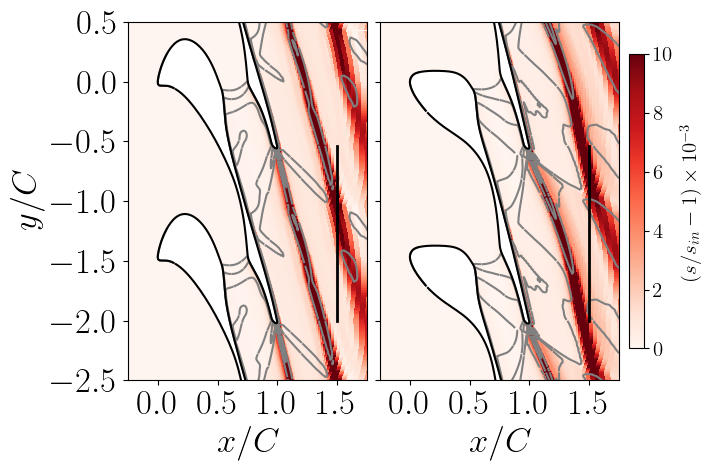

In [17]:
# %matplotlib auto

font = 25
markerscale=1

# Field
var = 's'
vmin = 2200
vmax = 2220
cmap = 'inferno_r'
cmap = 'Reds'

# Contours
var_contour = 'M'
vmin_contour = 1
vmax_contour = 2
contour_color = ['grey']
contour_style = ['solid']
contour_width = 1
levels = np.linspace(vmin_contour,vmax_contour,5)

fig,axs = plt.subplots(1,2,figsize=(7,5),sharex=True,sharey=True,constrained_layout=True)
plt.rcParams['text.usetex'] = True

# Field
for ii,dir_data in enumerate(dirs_data):
    for bl in range(n_bl):
        bl+=1
        s_in = comp_data[f'{ii}'][var+'_in']
        s = comp_data[f'{ii}'][f'block_{bl}'][var]/s_in-1
        vmin_ = 0
        vmax_ = vmax/s_in-1
        axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y'],\
                       s,\
                       vmin=vmin_,vmax=vmax_,cmap=cmap)
        axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']+pitch,\
                       s,\
                       vmin=vmin_,vmax=vmax_,cmap=cmap)
        axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']-pitch,\
                       s,\
                       vmin=vmin_,vmax=vmax_,cmap=cmap)
        axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']-2*pitch,\
                       s,\
                       vmin=vmin_,vmax=vmax_,cmap=cmap)
        axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']+2*pitch,\
                       s,\
                       vmin=vmin_,vmax=vmax_,cmap=cmap)
    
# Add colorbar
zero = np.zeros((1,1))
im = plt.pcolormesh(zero,zero,zero,vmin=0,vmax=10,cmap=cmap)
cbar = fig.colorbar(im,ax=axs,orientation='vertical',fraction=0.03,pad=0.02)
cbar.set_ticks([0,2,4,6,8,10])
cbar.set_label(label=r'$(s/s_{in}-1)\times10^{-3}$',size=font-10,weight='bold')
cbar.ax.tick_params(labelsize=font-10)
        
# Contours
for ii,dir_data in enumerate(dirs_data):
    for bl in range(n_bl):
        bl+=1
        axs[ii].contour(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y'],\
                       comp_data[f'{ii}'][f'block_{bl}'][var_contour],\
                       vmin=vmin_contour,vmax=vmax_contour,colors=contour_color,
                       linestyles=contour_style,levels=levels)
        axs[ii].contour(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']+pitch,\
                       comp_data[f'{ii}'][f'block_{bl}'][var_contour],\
                       vmin=vmin_contour,vmax=vmax_contour,colors=contour_color,
                       linestyles=contour_style,levels=levels)
        axs[ii].contour(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']-pitch,\
                       comp_data[f'{ii}'][f'block_{bl}'][var_contour],\
                       vmin=vmin_contour,vmax=vmax_contour,colors=contour_color,
                       linestyles=contour_style,levels=levels)
        axs[ii].contour(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']-2*pitch,\
                       comp_data[f'{ii}'][f'block_{bl}'][var_contour],\
                       vmin=vmin_contour,vmax=vmax_contour,colors=contour_color,
                       linestyles=contour_style,levels=levels)
        axs[ii].contour(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']+2*pitch,\
                       comp_data[f'{ii}'][f'block_{bl}'][var_contour],\
                       vmin=vmin_contour,vmax=vmax_contour,colors=contour_color,
                       linestyles=contour_style,levels=levels)
        
    # Add wall
    axs[ii].plot(comp_data[f'{ii}']['xw'],comp_data[f'{ii}']['yw'],'-k')
    axs[ii].plot(comp_data[f'{ii}']['xw'],comp_data[f'{ii}']['yw']+pitch,'-k')
    axs[ii].plot(comp_data[f'{ii}']['xw'],comp_data[f'{ii}']['yw']-pitch,'-k')

    axs[ii].set_xlabel(r'$x/C$',fontsize=font)
    if ii==0:
        axs[ii].set_ylabel(r'$y/C$',fontsize=font)
        axs[ii].set_yticks([-2.5,-2,-1.5,-1,-0.5,0,0.5],fontsize=font)
    axs[ii].set_xticks([-0.5,0.,0.5,1.0,1.5,2],fontsize=font)
    axs[ii].set_xlim(-0.25,1.75)
    axs[ii].set_ylim(-2.5,0.5)
    axs[ii].tick_params(axis='both',which='major',labelsize=font)
    axs[ii].set_aspect('equal')
    
    # Add measurement plane
    axs[ii].plot([1.5,1.5],[-2,-2+pitch],'-k',linewidth=2)



# plt.tight_layout()
# plt.savefig('Figures/NICFD5/entropy_field_comp_RANS.png',format='png')
plt.show()

# Plot entropy fields: manuscript

/tmp/ipykernel_372354/3529313880.py:33: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
/tmp/ipykernel_372354/3529313880.py:37: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
/tmp/ipykernel_372354/3529313880.py:41: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  axs[

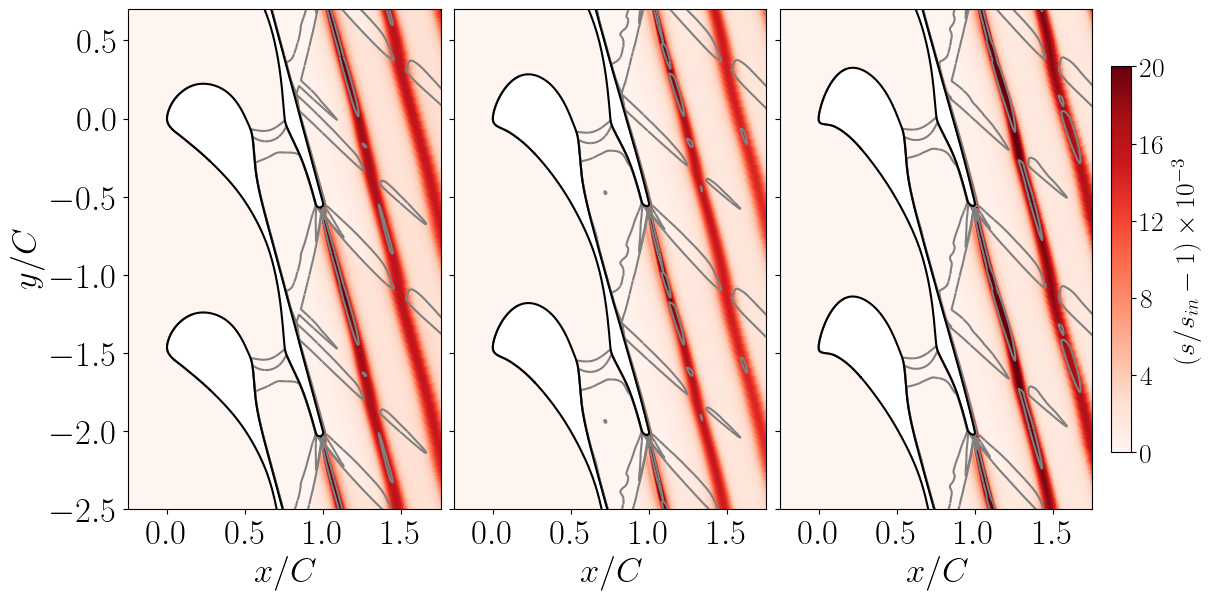

In [31]:
# %matplotlib auto

font = 25
markerscale=1

# Field
var = 's'
vmin = 2200
vmax = 2220
cmap = 'inferno_r'
cmap = 'Reds'

# Contours
var_contour = 'M'
vmin_contour = 1
vmax_contour = 2
contour_color = ['grey']
contour_style = ['solid']
contour_width = 1
levels = np.linspace(vmin_contour,vmax_contour,5)

fig,axs = plt.subplots(1,3,figsize=(12,7),sharex=True,sharey=True,constrained_layout=True)
plt.rcParams['text.usetex'] = True

# Field
for ii,dir_data in enumerate(dirs_data):
    for bl in range(n_bl):
        bl+=1
        s_in = comp_data[f'{ii}'][var+'_in']
        s = comp_data[f'{ii}'][f'block_{bl}'][var]/s_in-1
        vmin_ = 0
        vmax_ = vmax/s_in-1
        axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y'],\
                       s,\
                       vmin=vmin_,vmax=vmax_,cmap=cmap)
        axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']+pitch,\
                       s,\
                       vmin=vmin_,vmax=vmax_,cmap=cmap)
        axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']-pitch,\
                       s,\
                       vmin=vmin_,vmax=vmax_,cmap=cmap)
        axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']-2*pitch,\
                       s,\
                       vmin=vmin_,vmax=vmax_,cmap=cmap)
        axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']+2*pitch,\
                       s,\
                       vmin=vmin_,vmax=vmax_,cmap=cmap)
    
# Add colorbar
zero = np.zeros((1,1))
im = plt.pcolormesh(zero,zero,zero,vmin=0,vmax=20,cmap=cmap)
cbar = fig.colorbar(im,ax=axs,orientation='vertical',fraction=0.02,pad=0.02)
cbar.set_ticks([0,4,8,12,16,20])
cbar.set_label(label=r'$(s/s_{in}-1)\times10^{-3}$',size=font-5,weight='bold')
cbar.ax.tick_params(labelsize=font-5)
        
# Contours
for ii,dir_data in enumerate(dirs_data):
    for bl in range(n_bl):
        bl+=1
        axs[ii].contour(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y'],\
                       comp_data[f'{ii}'][f'block_{bl}'][var_contour],\
                       vmin=vmin_contour,vmax=vmax_contour,colors=contour_color,
                       linestyles=contour_style,levels=levels)
        axs[ii].contour(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']+pitch,\
                       comp_data[f'{ii}'][f'block_{bl}'][var_contour],\
                       vmin=vmin_contour,vmax=vmax_contour,colors=contour_color,
                       linestyles=contour_style,levels=levels)
        axs[ii].contour(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']-pitch,\
                       comp_data[f'{ii}'][f'block_{bl}'][var_contour],\
                       vmin=vmin_contour,vmax=vmax_contour,colors=contour_color,
                       linestyles=contour_style,levels=levels)
        axs[ii].contour(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']-2*pitch,\
                       comp_data[f'{ii}'][f'block_{bl}'][var_contour],\
                       vmin=vmin_contour,vmax=vmax_contour,colors=contour_color,
                       linestyles=contour_style,levels=levels)
        axs[ii].contour(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']+2*pitch,\
                       comp_data[f'{ii}'][f'block_{bl}'][var_contour],\
                       vmin=vmin_contour,vmax=vmax_contour,colors=contour_color,
                       linestyles=contour_style,levels=levels)
        
    # Add wall
    axs[ii].plot(comp_data[f'{ii}']['xw'],comp_data[f'{ii}']['yw'],'-k')
    axs[ii].plot(comp_data[f'{ii}']['xw'],comp_data[f'{ii}']['yw']+pitch,'-k')
    axs[ii].plot(comp_data[f'{ii}']['xw'],comp_data[f'{ii}']['yw']-pitch,'-k')

    # Ticks
    axs[ii].set_xlabel(r'$x/C$',fontsize=font)
    if ii==0:
        axs[ii].set_ylabel(r'$y/C$',fontsize=font)
        axs[ii].set_yticks([-2.5,-2,-1.5,-1,-0.5,0,0.5],fontsize=font)
    axs[ii].set_xticks([-0.5,0.,0.5,1.0,1.5,2],fontsize=font)
    axs[ii].set_xlim(-0.25,1.75)
    axs[ii].set_ylim(-2.5,0.5)
    axs[ii].set_ylim(-2.5,0.7)
    axs[ii].tick_params(axis='both',which='major',labelsize=font)
    axs[ii].set_aspect('equal')
    
    # # Add measurement plane
    # axs[ii].plot([1.1,1.1],[-1.75,-1.75+pitch],'-k',linewidth=2)
    # axs[ii].plot([1.3,1.3],[-1.1,-1.1+pitch],'-k',linewidth=2)
    # axs[ii].plot([1.5,1.5],[-1.9,-1.9+pitch],'-k',linewidth=2)

# Add text
# axs[0].annotate(r'RANS',xy=(0.,0.35),fontsize=font)
# axs[1].annotate(r'LES',xy=(0.,0.35),fontsize=font)

# plt.tight_layout()
# plt.savefig('Figures/Manuscript/entropy_field_comp_LES.png',format='png')
plt.show()

# Plot Mach number field: manuscript

/tmp/ipykernel_1386141/3969400489.py:30: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
/tmp/ipykernel_1386141/3969400489.py:34: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
/tmp/ipykernel_1386141/3969400489.py:38: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  a

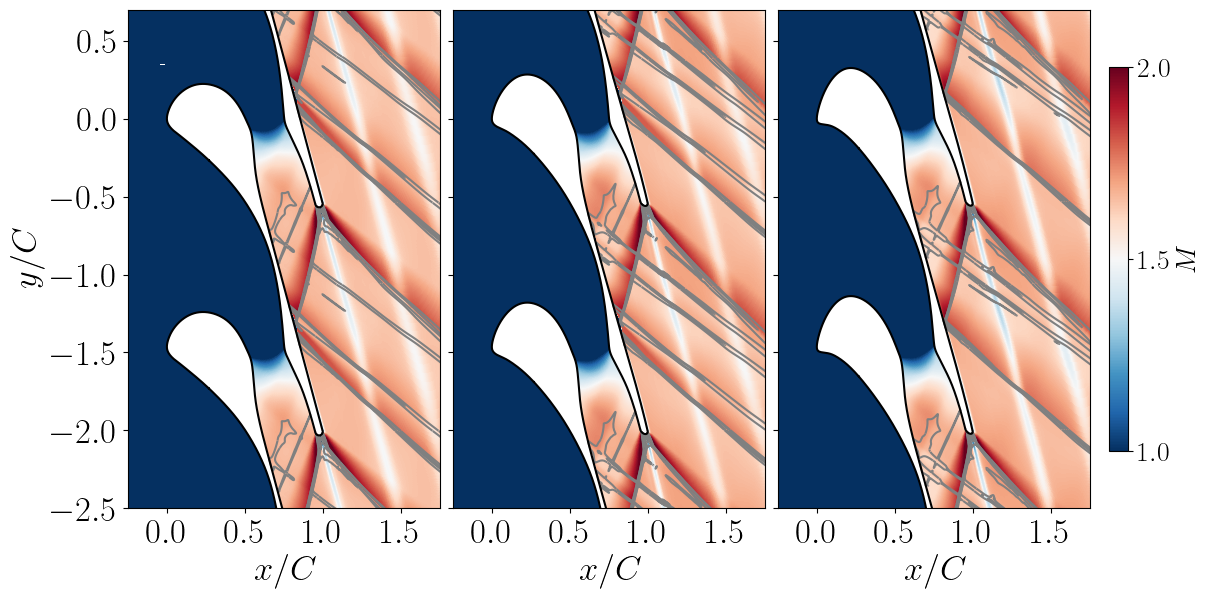

In [16]:
# %matplotlib auto

font = 25
markerscale=1

# Field
var = 'M'
vmin = 1.
vmax = 2
cmap = 'RdBu_r'

# Contours
var_contour = 'divloc'
vmin_contour = -1e5
vmax_contour = -1e4
nlevels = 2
contour_color = ['grey']
contour_style = ['solid']
contour_width = 1
levels = np.linspace(vmin_contour,vmax_contour,nlevels)

fig,axs = plt.subplots(1,3,figsize=(12,7),sharex=True,sharey=True,constrained_layout=True)
plt.rcParams['text.usetex'] = True

# Field
for ii,dir_data in enumerate(dirs_data):
    for bl in range(n_bl):
        bl+=1
        M = comp_data[f'{ii}'][f'block_{bl}'][var]
        axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y'],\
                       M,\
                       vmin=vmin,vmax=vmax,cmap=cmap)
        axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']+pitch,\
                       M,\
                       vmin=vmin,vmax=vmax,cmap=cmap)
        axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']-pitch,\
                       M,\
                       vmin=vmin,vmax=vmax,cmap=cmap)
        axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']-2*pitch,\
                       M,\
                       vmin=vmin,vmax=vmax,cmap=cmap)
        # axs[ii].pcolormesh(comp_data[f'{ii}'][f'block_{bl}']['x'],\
        #                comp_data[f'{ii}'][f'block_{bl}']['y']+2*pitch,\
        #                M,\
        #                vmin=vmin,vmax=vmax,cmap=cmap)
    
# Add colorbar
zero = np.zeros((1,1))
im = plt.pcolormesh(zero,zero,zero,vmin=vmin,vmax=vmax,cmap=cmap)
cbar = fig.colorbar(im,ax=axs,orientation='vertical',fraction=0.02,pad=0.02)
cbar.set_ticks([1,1.5,2])
cbar.set_label(label=r'$M$',size=font-5,weight='bold')
cbar.ax.tick_params(labelsize=font-5)
        
# Contours
for ii,dir_data in enumerate(dirs_data):
    for bl in range(n_bl):
        bl+=1
        axs[ii].contour(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y'],\
                       comp_data[f'{ii}'][f'block_{bl}'][var_contour],\
                       vmin=vmin_contour,vmax=vmax_contour,colors=contour_color,
                       linestyles=contour_style,levels=levels)
        axs[ii].contour(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']+pitch,\
                       comp_data[f'{ii}'][f'block_{bl}'][var_contour],\
                       vmin=vmin_contour,vmax=vmax_contour,colors=contour_color,
                       linestyles=contour_style,levels=levels)
        axs[ii].contour(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']-pitch,\
                       comp_data[f'{ii}'][f'block_{bl}'][var_contour],\
                       vmin=vmin_contour,vmax=vmax_contour,colors=contour_color,
                       linestyles=contour_style,levels=levels)
        axs[ii].contour(comp_data[f'{ii}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii}'][f'block_{bl}']['y']-2*pitch,\
                       comp_data[f'{ii}'][f'block_{bl}'][var_contour],\
                       vmin=vmin_contour,vmax=vmax_contour,colors=contour_color,
                       linestyles=contour_style,levels=levels)
        # axs[ii].contour(comp_data[f'{ii}'][f'block_{bl}']['x'],\
        #                comp_data[f'{ii}'][f'block_{bl}']['y']+2*pitch,\
        #                comp_data[f'{ii}'][f'block_{bl}'][var_contour],\
        #                vmin=vmin_contour,vmax=vmax_contour,colors=contour_color,
        #                linestyles=contour_style,levels=levels)
        
    # Add wall
    axs[ii].plot(comp_data[f'{ii}']['xw'],comp_data[f'{ii}']['yw'],'-k')
    axs[ii].plot(comp_data[f'{ii}']['xw'],comp_data[f'{ii}']['yw']+pitch,'-k')
    axs[ii].plot(comp_data[f'{ii}']['xw'],comp_data[f'{ii}']['yw']-pitch,'-k')

    # Ticks
    axs[ii].set_xlabel(r'$x/C$',fontsize=font)
    if ii==0:
        axs[ii].set_ylabel(r'$y/C$',fontsize=font)
        axs[ii].set_yticks([-2.5,-2,-1.5,-1,-0.5,0,0.5],fontsize=font)
    axs[ii].set_xticks([-0.5,0.,0.5,1.0,1.5,2],fontsize=font)
    axs[ii].set_xlim(-0.25,1.75)
    axs[ii].set_ylim(-2.5,0.5)
    axs[ii].set_ylim(-2.5,0.7)
    axs[ii].tick_params(axis='both',which='major',labelsize=font)
    axs[ii].set_aspect('equal')
    
    # Add measurement plane
    # axs[ii].plot([1.5,1.5],[-2,-2+pitch],'-k',linewidth=2)
    
    # # Add BL line: PS
    # axs[ii].plot([comp_data[f'{ii}']['xw'][0],comp_data[f'{ii}']['xw'][0]-0.03],
    #                [comp_data[f'{ii}']['yw'][0],comp_data[f'{ii}']['yw'][0]-0.1],'-r',linewidth=2)

# Add text
# axs[0].annotate(r'RANS',xy=(0.,0.35),fontsize=font)
# axs[1].annotate(r'LES',xy=(0.,0.35),fontsize=font)

# plt.tight_layout()
# plt.savefig('Figures/Manuscript/M_field_comp_LES.png',format='png')
# plt.savefig('Figures/AST/M_field_comp_LES.png',format='png')
plt.show()

# Zoom on recirculation bubble (LE)

In [7]:
import scipy.interpolate as si
import matplotlib

def plot_stream(ax,lim,u_flat,v_flat,x_flat,y_flat,xw_r,yw_r):

    # Create cartesian grid
    X,Y = create_cart(50,50,lim)

    # Interpolate data on regular grid
    u_interp = si.griddata((x_flat,y_flat),u_flat,(X,Y),method='nearest')
    v_interp = si.griddata((x_flat,y_flat),v_flat,(X,Y),method='nearest')

    # Mask
    coord_w = np.vstack((xw_r,yw_r)).T
    poly = matplotlib.patches.Polygon(coord_w,closed=True)
    samp_points = np.vstack((X.flatten(),Y.flatten())).T
    mask = poly.get_path().contains_points(samp_points)
    
    u_mask = np.ma.array(u_interp,mask=mask)
    v_mask = np.ma.array(v_interp,mask=mask)

    # Stream plot
    ax.streamplot(X,Y,u_mask,v_mask,density=[3,1.5], \
                   integration_direction="forward",maxlength=5, \
                   arrowstyle="->",linewidth=1,color='k')
    
def create_cart(nx,ny,lim):

    xmin,xmax,ymin,ymax = lim[0],lim[1],lim[2],lim[3]
    x   = np.linspace(xmin,xmax,nx)
    y   = np.linspace(ymin,ymax,ny)
    X,Y = np.meshgrid(x,y)

    return X,Y

/tmp/ipykernel_416197/601511307.py:25: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  axs[ii].pcolormesh(comp_data[f'{ii+j}'][f'block_{bl}']['x'],\
/tmp/ipykernel_416197/601511307.py:29: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  axs[ii].pcolormesh(comp_data[f'{ii+j}'][f'block_{bl}']['x'],\


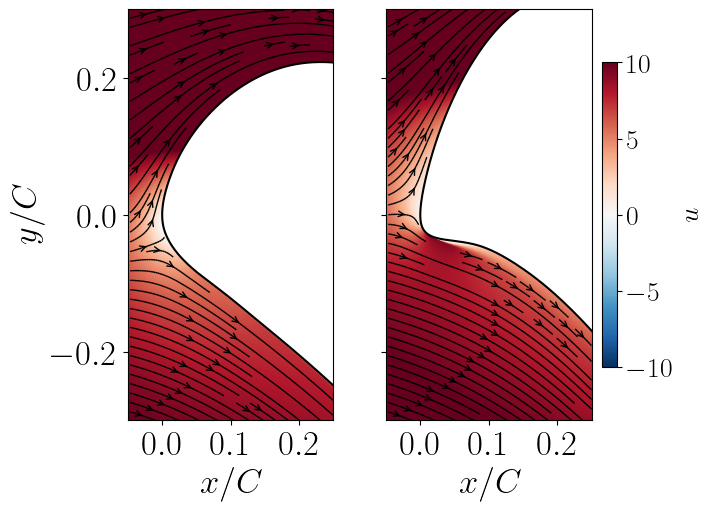

In [8]:
# %matplotlib auto

font = 25
markerscale=1

# Field
var = 'u'
vmin = -10
vmax = 10
cmap = 'Reds'
cmap = 'RdBu_r'

fig,axs = plt.subplots(1,2,figsize=(7,5),sharex=True,sharey=True,constrained_layout=True)
plt.rcParams['text.usetex'] = True

# Field
dirs_data_comp = [dirs_data[0],dirs_data[-1]]
j = 0
for ii,dir_data in enumerate(dirs_data_comp):
    if ii==1:
        j=1
    for bl in range(n_bl):
        bl+=1
        M = comp_data[f'{ii+j}'][f'block_{bl}'][var]
        axs[ii].pcolormesh(comp_data[f'{ii+j}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii+j}'][f'block_{bl}']['y'],\
                       M,\
                       vmin=vmin,vmax=vmax,cmap=cmap)
        axs[ii].pcolormesh(comp_data[f'{ii+j}'][f'block_{bl}']['x'],\
                       comp_data[f'{ii+j}'][f'block_{bl}']['y']-pitch,\
                       M,\
                       vmin=vmin,vmax=vmax,cmap=cmap)
    
# Add colorbar
zero = np.zeros((1,1))
im = plt.pcolormesh(zero,zero,zero,vmin=vmin,vmax=vmax,cmap=cmap)
cbar = fig.colorbar(im,ax=axs,orientation='vertical',fraction=0.03,pad=0.02)
# cbar.set_ticks([1,1.5,2])
cbar.set_label(label=fr'${var}$',size=font-5,weight='bold')
cbar.ax.tick_params(labelsize=font-5)
        
# Streamlines
x1 = -0.05
x2 = 0.25
y1 = -0.3
y2 = 0.3
lim = [x1,x2,y1,y2]
# lim = [0,0.5,-0.5,0]
j = 0
for ii,dir_data in enumerate(dirs_data_comp):
    if ii==1:
        j=1
    u_flat = comp_data[f'{ii+j}']['u_flat'].copy()
    v_flat = comp_data[f'{ii+j}']['v_flat'].copy()
    x_flat = comp_data[f'{ii+j}']['x_flat'].copy()
    y_flat = comp_data[f'{ii+j}']['y_flat'].copy()
    xw_r = comp_data[f'{ii+j}']['xw'].copy()
    yw_r = comp_data[f'{ii+j}']['yw'].copy()
    plot_stream(axs[ii],lim,u_flat,v_flat,x_flat,y_flat,xw_r,yw_r)
        
    # Add wall
    axs[ii].plot(xw_r,yw_r,'-k')
    axs[ii].plot([xw_r[-1],xw_r[0]],[yw_r[-1],yw_r[0]],'-k')
    axs[ii].plot(xw_r,yw_r+pitch,'-k')
    axs[ii].plot(xw_r,yw_r-pitch,'-k')

    # Ticks
    axs[ii].set_xlabel(r'$x/C$',fontsize=font)
    if ii==0:
        axs[ii].set_ylabel(r'$y/C$',fontsize=font)
        # axs[ii].set_yticks([-2.5,-2,-1.5,-1,-0.5,0,0.5],fontsize=font)
    axs[ii].set_xticks([0,0.1,0.2],fontsize=font)
    axs[ii].set_xlim(x1,x2)
    axs[ii].set_ylim(y1,y2)
    axs[ii].tick_params(axis='both',which='major',labelsize=font)
    axs[ii].set_aspect('equal')
    
    # Add measurement plane
    # axs[ii].plot([1.5,1.5],[-2,-2+pitch],'-k',linewidth=2)
    
    # # Add BL line: PS
    # axs[ii].plot([comp_data[f'{ii}']['xw'][0],comp_data[f'{ii}']['xw'][0]-0.03],
    #                [comp_data[f'{ii}']['yw'][0],comp_data[f'{ii}']['yw'][0]-0.1],'-r',linewidth=2)

# Add text
# axs[0].annotate(r'RANS',xy=(0.,0.35),fontsize=font)
# axs[1].annotate(r'LES',xy=(0.,0.35),fontsize=font)

# plt.tight_layout()
# plt.savefig('Figures/Manuscript/Streamlines_comp_LES.png',format='png')
plt.show()